# Data_Missing_Values

> **Project Phase**: Phase 3: Missing Value & Data Quality Analysis (11 Feb – 13 Feb 2026)

### Notebook Overview
- **Purpose**: Analyze missing values, field completeness, and data quality across the 6 relational source tables.
- **Input Data**: `Raw relational CSV tables in Datasets/ (01_people.csv to 06_skills.csv + _add files)`
- **Key Processing**: Null count calculation, column-wise missing percentage assessment, data integrity checks.
- **Primary Output**: `Data quality assessment reports and missing value distribution insights.`

---


`01_people.csv` data set Cleaning missing values

LOADING DATASET...

INITIAL DATASET INFORMATION
Initial Shape: (54933, 5)

Columns:
['person_id', 'name', 'email', 'phone', 'linkedin']

Missing Values:
person_id        0
name           114
email        53340
phone        53100
linkedin     46395
dtype: int64

Duplicate Rows: 0

Sample Rows:
   person_id                                               name email phone  \
0          1                             Database Administrator   NaN   NaN   
1          2                             Database Administrator   NaN   NaN   
2          3                      Oracle Database Administrator   NaN   NaN   
3          4  Amazon Redshift Administrator and ETL Develope...   NaN   NaN   
4          5             Scrum Master Scrum Master Scrum Master   NaN   NaN   

  linkedin  
0      NaN  
1      NaN  
2      NaN  
3      NaN  
4      NaN  

DROPPING IRRELEVANT COLUMNS...
Dropped Columns: ['email', 'phone', 'linkedin']

RENAMING COLUMN...
Renamed:
'name' → 'profile_title'

REMOVING NULL TITL

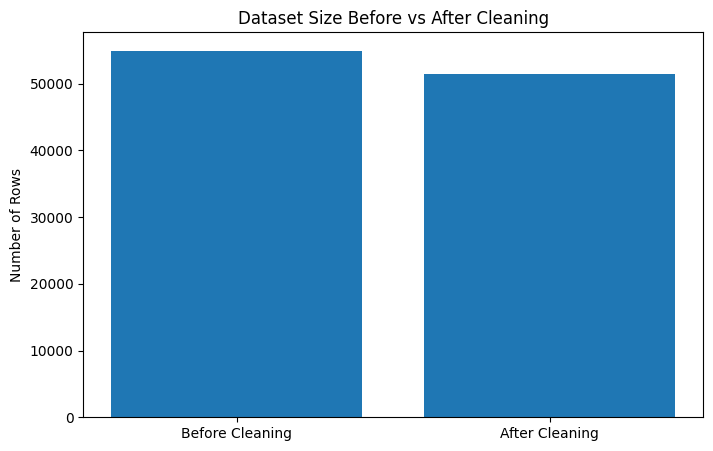

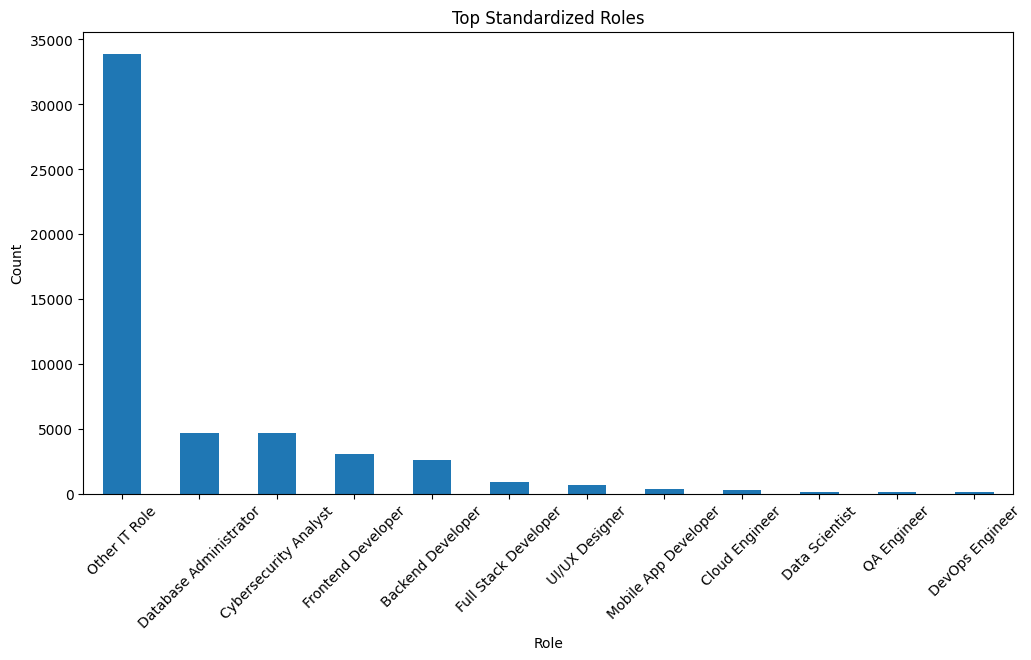

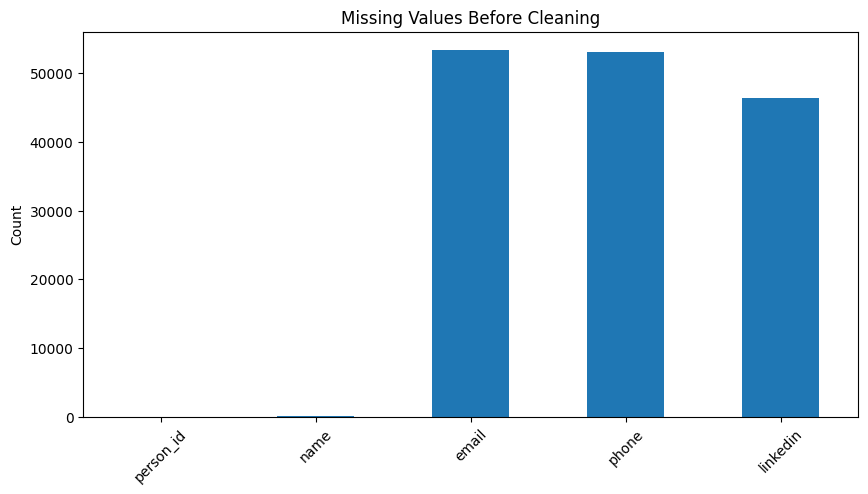


PROCESS COMPLETED SUCCESSFULLY

OUTPUT GENERATED:
1. Cleaned Dataset
2. Standardized Roles
3. Dataset Statistics
4. Cleaning Analysis
5. Visualization Plots

Saved File:
01_people_add.csv



In [1]:
# ============================================================
# NLP PROJECT - PEOPLE DATASET CLEANING & ROLE STANDARDIZATION
# ============================================================

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

# ============================================================
# 1. LOAD DATASET
# ============================================================

input_path = "/content/drive/MyDrive/NLP_Project-2/Datasets/01_people.csv"
output_path = "/content/drive/MyDrive/NLP_Project-2/Datasets/01_people_add.csv"

print("=" * 60)
print("LOADING DATASET...")
print("=" * 60)

df = pd.read_csv(input_path)

# ============================================================
# 2. INITIAL DATASET INFORMATION
# ============================================================

print("\nINITIAL DATASET INFORMATION")
print("=" * 60)

print(f"Initial Shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nSample Rows:")
print(df.head())

# ============================================================
# 3. DROP IRRELEVANT COLUMNS
# ============================================================

print("\n" + "=" * 60)
print("DROPPING IRRELEVANT COLUMNS...")
print("=" * 60)

columns_to_drop = ['email', 'phone', 'linkedin']

existing_cols = [col for col in columns_to_drop if col in df.columns]

df.drop(columns=existing_cols, inplace=True)

print("Dropped Columns:", existing_cols)

# ============================================================
# 4. RENAME COLUMN
# ============================================================

print("\n" + "=" * 60)
print("RENAMING COLUMN...")
print("=" * 60)

df.rename(columns={'name': 'profile_title'}, inplace=True)

print("Renamed:")
print("'name' → 'profile_title'")

# ============================================================
# 5. REMOVE NULL TITLES
# ============================================================

print("\n" + "=" * 60)
print("REMOVING NULL TITLES...")
print("=" * 60)

before_null = df.shape[0]

df = df[df['profile_title'].notnull()]

after_null = df.shape[0]

print(f"Rows Removed: {before_null - after_null}")

# ============================================================
# 6. CLEAN TEXT
# ============================================================

print("\n" + "=" * 60)
print("CLEANING PROFILE TITLES...")
print("=" * 60)

def clean_text(text):

    text = str(text)

    # lowercase
    text = text.lower()

    # remove special characters
    text = re.sub(r'[^a-zA-Z0-9\s/+-]', ' ', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['profile_title'] = df['profile_title'].apply(clean_text)

# ============================================================
# 7. REMOVE DUPLICATE WORD REPETITIONS
# ============================================================

print("\n" + "=" * 60)
print("REMOVING DUPLICATE WORD REPETITIONS...")
print("=" * 60)

def remove_duplicate_words(text):

    words = text.split()

    cleaned = []

    for word in words:
        if len(cleaned) == 0 or cleaned[-1] != word:
            cleaned.append(word)

    return " ".join(cleaned)

df['profile_title'] = df['profile_title'].apply(remove_duplicate_words)

# ============================================================
# 8. REMOVE GARBAGE / INVALID TITLES
# ============================================================

print("\n" + "=" * 60)
print("REMOVING GARBAGE TITLES...")
print("=" * 60)

garbage_keywords = [
    'mrs',
    'mr',
    'miss',
    'volunteer',
    'student',
    'unknown',
    'none'
]

company_keywords = [
    'llc',
    'inc',
    'ltd',
    'corporation',
    'technologies',
    'solutions',
    'company'
]

def is_valid_title(text):

    # remove very short rows
    if len(text.split()) < 2:
        return False

    # remove garbage keywords
    for word in garbage_keywords:
        if word in text:
            return False

    # remove company names
    for word in company_keywords:
        if word in text:
            return False

    return True

before_clean = df.shape[0]

df = df[df['profile_title'].apply(is_valid_title)]

after_clean = df.shape[0]

print(f"Rows Removed: {before_clean - after_clean}")

# ============================================================
# 9. STANDARDIZE ROLE NAMES
# ============================================================

print("\n" + "=" * 60)
print("STANDARDIZING ROLES...")
print("=" * 60)

role_mapping = {

    # DATABASE
    r'.*(oracle|sql|dba|database).*':
        'Database Administrator',

    # FRONTEND
    r'.*(frontend|front end|react|angular|vue|ui developer).*':
        'Frontend Developer',

    # BACKEND
    r'.*(backend|back end|java developer|spring|node js|django).*':
        'Backend Developer',

    # FULL STACK
    r'.*(full stack).*':
        'Full Stack Developer',

    # DEVOPS
    r'.*(devops|jenkins|kubernetes|docker|terraform).*':
        'DevOps Engineer',

    # CLOUD
    r'.*(cloud|aws|azure|gcp).*':
        'Cloud Engineer',

    # DATA SCIENCE
    r'.*(data scientist|data science|analytics).*':
        'Data Scientist',

    # ML ENGINEER
    r'.*(machine learning|ml engineer|ai engineer|deep learning).*':
        'Machine Learning Engineer',

    # CYBERSECURITY
    r'.*(cyber|security|penetration|ethical hacking).*':
        'Cybersecurity Analyst',

    # MOBILE
    r'.*(android|ios|flutter|react native|mobile).*':
        'Mobile App Developer',

    # QA
    r'.*(qa|testing|test engineer|selenium).*':
        'QA Engineer',

    # UI UX
    r'.*(ux|ui ux|figma|designer).*':
        'UI/UX Designer'
}

def map_role(title):

    for pattern, role in role_mapping.items():
        if re.search(pattern, title):
            return role

    return "Other IT Role"

df['standardized_role'] = df['profile_title'].apply(map_role)

# ============================================================
# 10. REMOVE DUPLICATE ROWS
# ============================================================

print("\n" + "=" * 60)
print("REMOVING DUPLICATES...")
print("=" * 60)

before_dup = df.shape[0]

df.drop_duplicates(inplace=True)

after_dup = df.shape[0]

print(f"Duplicates Removed: {before_dup - after_dup}")

# ============================================================
# 11. FINAL DATASET INFORMATION
# ============================================================

print("\n" + "=" * 60)
print("FINAL DATASET INFORMATION")
print("=" * 60)

print(f"Final Shape: {df.shape}")

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFinal Columns:")
print(df.columns.tolist())

print("\nSample Cleaned Data:")
print(df.head())

# ============================================================
# 12. ROLE DISTRIBUTION
# ============================================================

print("\n" + "=" * 60)
print("ROLE DISTRIBUTION")
print("=" * 60)

role_counts = df['standardized_role'].value_counts()

print(role_counts)

# ============================================================
# 13. SAVE CLEANED DATASET
# ============================================================

print("\n" + "=" * 60)
print("SAVING CLEANED DATASET...")
print("=" * 60)

df.to_csv(output_path, index=False)

print(f"Saved Successfully:")
print(output_path)

# ============================================================
# 14. PLOTS
# ============================================================

print("\n" + "=" * 60)
print("GENERATING PLOTS...")
print("=" * 60)

# ------------------------------------------------------------
# Plot 1 - Before vs After Rows
# ------------------------------------------------------------

before_rows = before_null
after_rows = df.shape[0]

plt.figure(figsize=(8, 5))

plt.bar(
    ['Before Cleaning', 'After Cleaning'],
    [before_rows, after_rows]
)

plt.title("Dataset Size Before vs After Cleaning")
plt.ylabel("Number of Rows")

plt.show()

# ------------------------------------------------------------
# Plot 2 - Role Distribution
# ------------------------------------------------------------

top_roles = df['standardized_role'].value_counts().head(12)

plt.figure(figsize=(12, 6))

top_roles.plot(kind='bar')

plt.title("Top Standardized Roles")
plt.xlabel("Role")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# ------------------------------------------------------------
# Plot 3 - Missing Values Before Cleaning
# ------------------------------------------------------------

missing_before = pd.read_csv(input_path).isnull().sum()

plt.figure(figsize=(10, 5))

missing_before.plot(kind='bar')

plt.title("Missing Values Before Cleaning")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# ============================================================
# 15. FINAL MESSAGE
# ============================================================

print("\n" + "=" * 60)
print("PROCESS COMPLETED SUCCESSFULLY")
print("=" * 60)

print("""
OUTPUT GENERATED:
1. Cleaned Dataset
2. Standardized Roles
3. Dataset Statistics
4. Cleaning Analysis
5. Visualization Plots

Saved File:
01_people_add.csv
""")

`02_abilities.csv` data set Cleaning missing values

LOADING ABILITIES DATASET...

INITIAL DATASET INFORMATION
Initial Shape: (1219473, 2)

Columns:
['person_id', 'ability']

Data Types:
person_id     int64
ability      object
dtype: object

Missing Values:
person_id    0
ability      0
dtype: int64

Duplicate Rows:
34656

Sample Rows:
   person_id                           ability
0          1  Installation and Building Server
1          1                   Running Backups
2          1   Recovering and Restoring Models
3          1     Support various MS SQL Server
4          1           MS SQL Server 2005/2008

REMOVING NULL ROWS...
Rows Removed Due to Nulls: 0

CLEANING ABILITY TEXT...

REMOVING EMPTY ABILITIES...
Empty Ability Rows Removed: 0

REMOVING DUPLICATES...
Duplicate Rows Removed: 39381

FINAL DATASET INFORMATION
Final Shape: (1180092, 2)

Final Columns:
['person_id', 'ability']

Missing Values After Cleaning:
person_id    0
ability      0
dtype: int64

Duplicate Rows After Cleaning:
0

Sample Cleaned Rows:
   person_id     

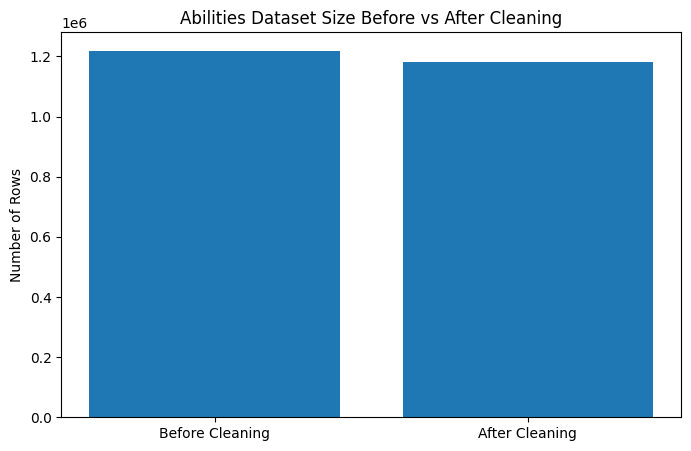

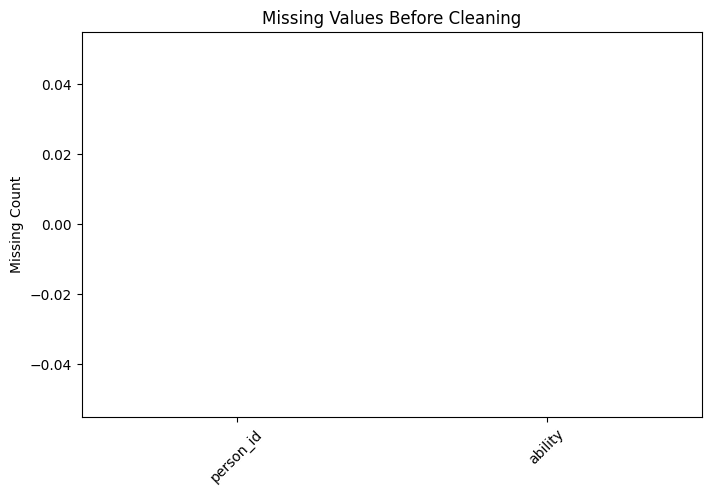

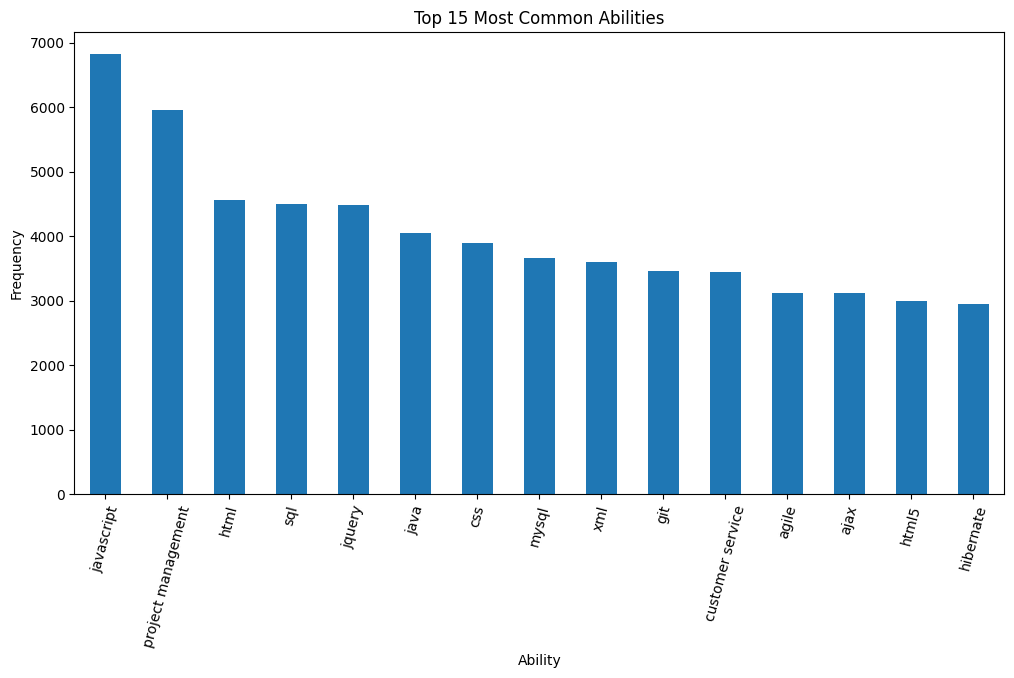

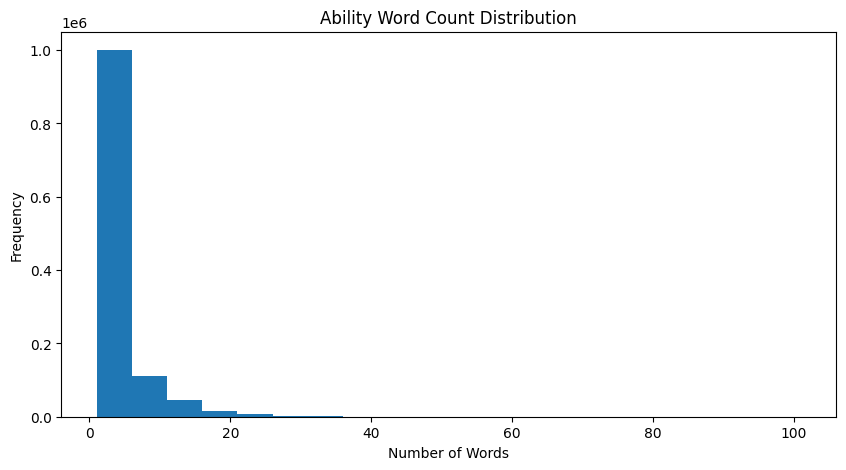


PROCESS COMPLETED SUCCESSFULLY

SUMMARY:

Initial Shape  : (1219473, 2)
Final Shape    : (1180092, 3)

Cleaning Operations Performed:
1. Removed Null Rows
2. Cleaned Ability Text
3. Removed Empty Abilities
4. Removed Duplicate Rows
5. Standardized Text Formatting

Saved File:
02_abilities_add.csv



In [2]:
# ============================================================
# NLP PROJECT - ABILITIES DATASET CLEANING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# ============================================================
# 1. LOAD DATASET
# ============================================================

input_path = "/content/drive/MyDrive/NLP_Project-2/Datasets/02_abilities.csv"
output_path = "/content/drive/MyDrive/NLP_Project-2/Datasets/02_abilities_add.csv"

print("=" * 60)
print("LOADING ABILITIES DATASET...")
print("=" * 60)

df = pd.read_csv(input_path)

# ============================================================
# 2. INITIAL DATASET INFORMATION
# ============================================================

print("\nINITIAL DATASET INFORMATION")
print("=" * 60)

print(f"Initial Shape: {df.shape}")

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nSample Rows:")
print(df.head())

# ============================================================
# 3. STORE INITIAL STATS
# ============================================================

initial_rows = df.shape[0]
initial_columns = df.shape[1]

missing_before = df.isnull().sum()

# ============================================================
# 4. REMOVE NULL ROWS (IF ANY)
# ============================================================

print("\n" + "=" * 60)
print("REMOVING NULL ROWS...")
print("=" * 60)

before_null = df.shape[0]

df.dropna(inplace=True)

after_null = df.shape[0]

print(f"Rows Removed Due to Nulls: {before_null - after_null}")

# ============================================================
# 5. CLEAN TEXT
# ============================================================

print("\n" + "=" * 60)
print("CLEANING ABILITY TEXT...")
print("=" * 60)

def clean_text(text):

    text = str(text)

    # lowercase
    text = text.lower()

    # remove special characters
    text = re.sub(r'[^a-zA-Z0-9\s/+.-]', ' ', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['ability'] = df['ability'].apply(clean_text)

# ============================================================
# 6. REMOVE EMPTY ABILITIES
# ============================================================

print("\n" + "=" * 60)
print("REMOVING EMPTY ABILITIES...")
print("=" * 60)

before_empty = df.shape[0]

df = df[df['ability'].str.strip() != ""]

after_empty = df.shape[0]

print(f"Empty Ability Rows Removed: {before_empty - after_empty}")

# ============================================================
# 7. REMOVE DUPLICATES
# ============================================================

print("\n" + "=" * 60)
print("REMOVING DUPLICATES...")
print("=" * 60)

before_dup = df.shape[0]

df.drop_duplicates(inplace=True)

after_dup = df.shape[0]

print(f"Duplicate Rows Removed: {before_dup - after_dup}")

# ============================================================
# 8. FINAL DATASET INFORMATION
# ============================================================

print("\n" + "=" * 60)
print("FINAL DATASET INFORMATION")
print("=" * 60)

print(f"Final Shape: {df.shape}")

print("\nFinal Columns:")
print(df.columns.tolist())

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nDuplicate Rows After Cleaning:")
print(df.duplicated().sum())

print("\nSample Cleaned Rows:")
print(df.head())

# ============================================================
# 9. ABILITY LENGTH ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("ABILITY LENGTH ANALYSIS")
print("=" * 60)

df['ability_word_count'] = df['ability'].apply(lambda x: len(str(x).split()))

print(df['ability_word_count'].describe())

# ============================================================
# 10. TOP MOST COMMON ABILITIES
# ============================================================

print("\n" + "=" * 60)
print("TOP COMMON ABILITIES")
print("=" * 60)

top_abilities = df['ability'].value_counts().head(20)

print(top_abilities)

# ============================================================
# 11. SAVE CLEANED DATASET
# ============================================================

print("\n" + "=" * 60)
print("SAVING CLEANED DATASET...")
print("=" * 60)

# remove temporary column before saving
df.drop(columns=['ability_word_count'], inplace=True)

df.to_csv(output_path, index=False)

print(f"Dataset Saved Successfully:")
print(output_path)

# ============================================================
# 12. VISUALIZATIONS
# ============================================================

print("\n" + "=" * 60)
print("GENERATING PLOTS...")
print("=" * 60)

# ------------------------------------------------------------
# Plot 1 - Before vs After Cleaning
# ------------------------------------------------------------

final_rows = df.shape[0]

plt.figure(figsize=(8, 5))

plt.bar(
    ['Before Cleaning', 'After Cleaning'],
    [initial_rows, final_rows]
)

plt.title("Abilities Dataset Size Before vs After Cleaning")
plt.ylabel("Number of Rows")

plt.show()

# ------------------------------------------------------------
# Plot 2 - Missing Values Before Cleaning
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

missing_before.plot(kind='bar')

plt.title("Missing Values Before Cleaning")
plt.ylabel("Missing Count")

plt.xticks(rotation=45)

plt.show()

# ------------------------------------------------------------
# Plot 3 - Top 15 Most Common Abilities
# ------------------------------------------------------------

top_plot = df['ability'].value_counts().head(15)

plt.figure(figsize=(12, 6))

top_plot.plot(kind='bar')

plt.title("Top 15 Most Common Abilities")
plt.xlabel("Ability")
plt.ylabel("Frequency")

plt.xticks(rotation=75)

plt.show()

# ------------------------------------------------------------
# Plot 4 - Ability Word Count Distribution
# ------------------------------------------------------------

df['ability_word_count'] = df['ability'].apply(
    lambda x: len(str(x).split())
)

plt.figure(figsize=(10, 5))

plt.hist(df['ability_word_count'], bins=20)

plt.title("Ability Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

# ============================================================
# 13. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("PROCESS COMPLETED SUCCESSFULLY")
print("=" * 60)

print(f"""
SUMMARY:

Initial Shape  : ({initial_rows}, {initial_columns})
Final Shape    : {df.shape}

Cleaning Operations Performed:
1. Removed Null Rows
2. Cleaned Ability Text
3. Removed Empty Abilities
4. Removed Duplicate Rows
5. Standardized Text Formatting

Saved File:
02_abilities_add.csv
""")

`03_education.csv` data set Cleaning missing values

LOADING EDUCATION DATASET...

INITIAL DATASET INFORMATION
Initial Shape: (75999, 5)

Columns:
['person_id', 'institution', 'program', 'start_date', 'location']

Data Types:
person_id       int64
institution    object
program        object
start_date     object
location       object
dtype: object

Missing Values:
person_id          0
institution     1569
program         7761
start_date     21129
location       23256
dtype: int64

Duplicate Rows:
51

Sample Rows:
   person_id                       institution  \
0          1              Lead City University   
1          2            lagos state university   
2          3   JNTU - Kakinada, Andhra Pradesh   
3          4         University of Informatics   
4          5  Virginia Commomwealth University   

                                             program start_date  \
0                                Bachelor of Science    07/2013   
1                            bsc in computer science        NaN   
2  Master of Computer Applicatio

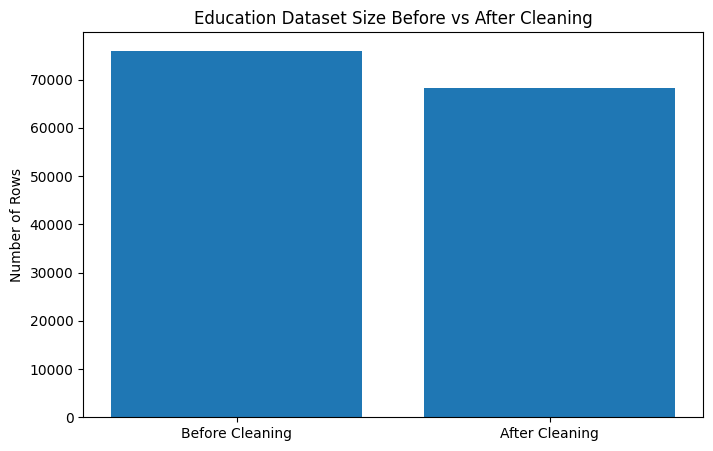

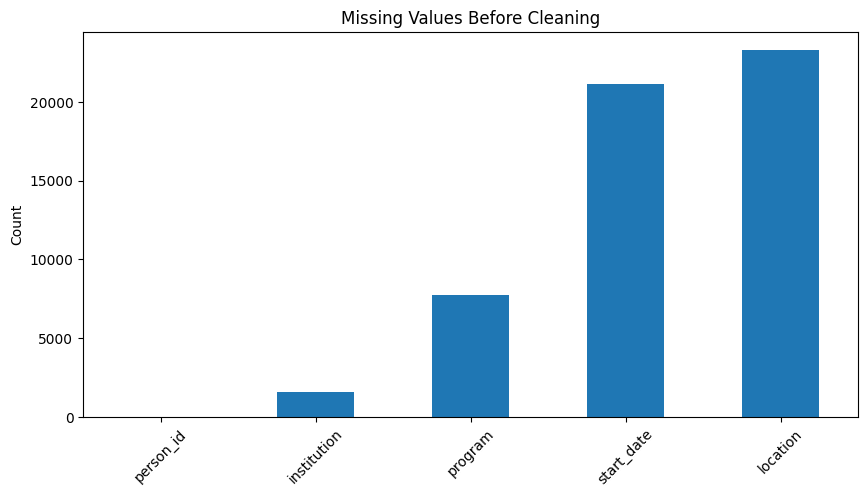

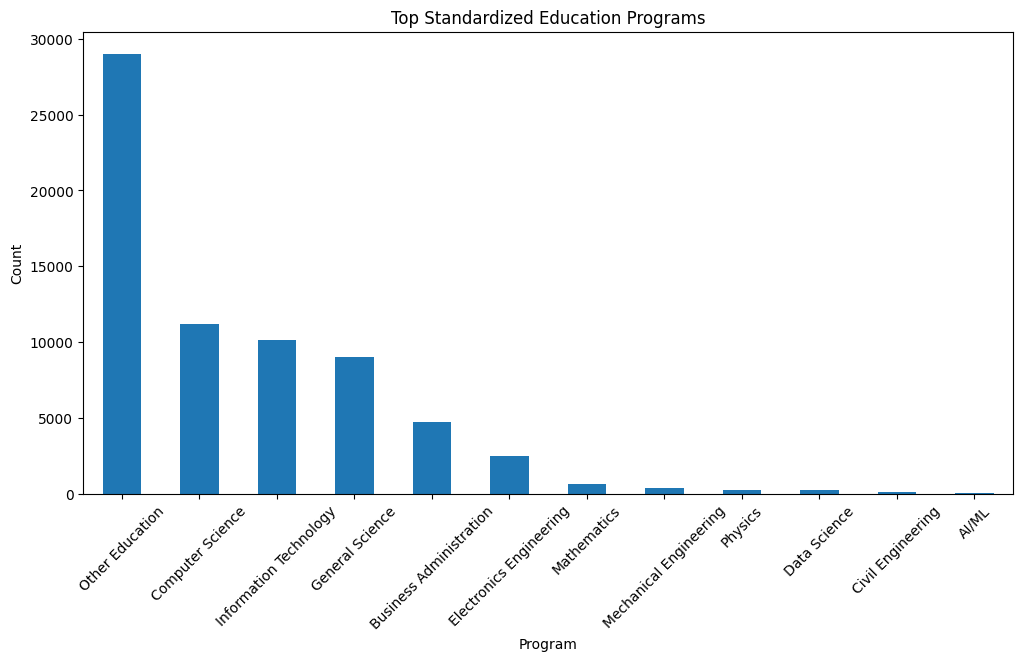

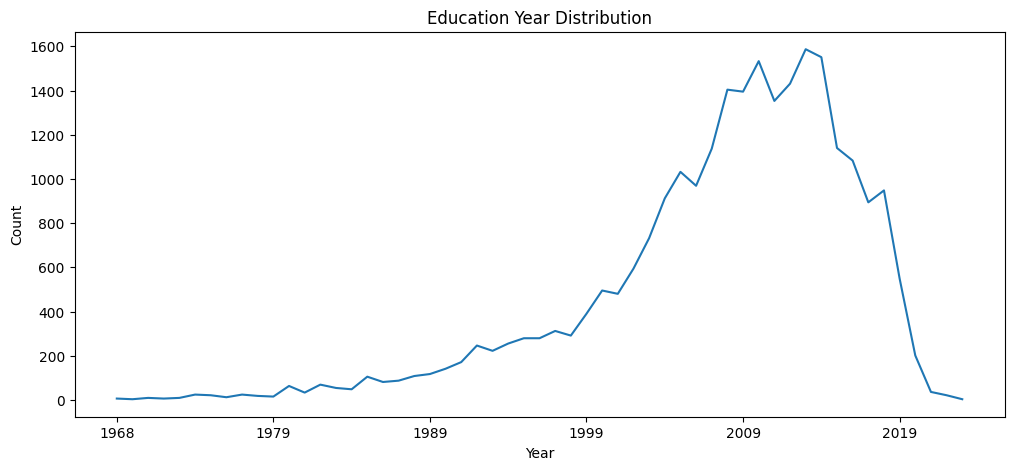

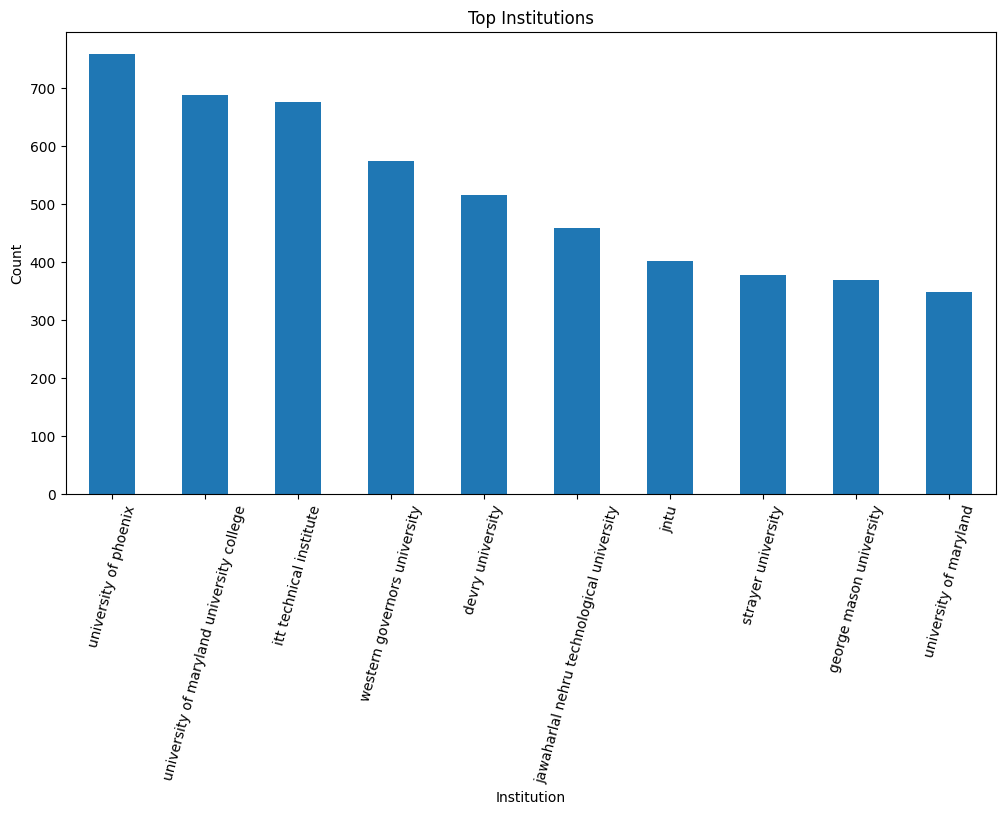


PROCESS COMPLETED SUCCESSFULLY

SUMMARY:

Initial Shape  : (75999, 5)
Final Shape    : (68187, 7)

Cleaning Operations Performed:
1. Removed Empty Rows
2. Cleaned Institution Names
3. Cleaned Program Names
4. Standardized Education Programs
5. Extracted Education Years
6. Removed Duplicate Rows
7. Normalized Text Formatting

Saved File:
03_education_add.csv



In [3]:
# ============================================================
# NLP PROJECT - EDUCATION DATASET CLEANING & STANDARDIZATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# ============================================================
# 1. LOAD DATASET
# ============================================================

input_path = "/content/drive/MyDrive/NLP_Project-2/Datasets/03_education.csv"
output_path = "/content/drive/MyDrive/NLP_Project-2/Datasets/03_education_add.csv"

print("=" * 70)
print("LOADING EDUCATION DATASET...")
print("=" * 70)

df = pd.read_csv(input_path)

# ============================================================
# 2. INITIAL DATASET INFORMATION
# ============================================================

print("\nINITIAL DATASET INFORMATION")
print("=" * 70)

print(f"Initial Shape: {df.shape}")

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nSample Rows:")
print(df.head())

# ============================================================
# 3. STORE INITIAL STATS
# ============================================================

initial_rows = df.shape[0]
initial_columns = df.shape[1]

missing_before = df.isnull().sum()

# ============================================================
# 4. REMOVE COMPLETELY EMPTY ROWS
# ============================================================

print("\n" + "=" * 70)
print("REMOVING COMPLETELY EMPTY ROWS...")
print("=" * 70)

before_empty = df.shape[0]

df.dropna(how='all', inplace=True)

after_empty = df.shape[0]

print(f"Completely Empty Rows Removed: {before_empty - after_empty}")

# ============================================================
# 5. CLEAN TEXT COLUMNS
# ============================================================

print("\n" + "=" * 70)
print("CLEANING TEXT COLUMNS...")
print("=" * 70)

text_columns = ['institution', 'program', 'location']

def clean_text(text):

    if pd.isnull(text):
        return np.nan

    text = str(text)

    # lowercase
    text = text.lower()

    # remove special characters
    text = re.sub(r'[^a-zA-Z0-9\s/,+.-]', ' ', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

for col in text_columns:
    if col in df.columns:
        df[col] = df[col].apply(clean_text)

print("Text Cleaning Completed.")

# ============================================================
# 6. REMOVE ROWS WITH MISSING PROGRAMS
# ============================================================

print("\n" + "=" * 70)
print("REMOVING ROWS WITH MISSING PROGRAMS...")
print("=" * 70)

before_program = df.shape[0]

df = df[df['program'].notnull()]

after_program = df.shape[0]

print(f"Rows Removed: {before_program - after_program}")

# ============================================================
# 7. STANDARDIZE EDUCATION PROGRAMS
# ============================================================

print("\n" + "=" * 70)
print("STANDARDIZING EDUCATION PROGRAMS...")
print("=" * 70)

program_mapping = {

    # COMPUTER SCIENCE
    r'.*(computer science|cse|cs engineering|software engineering).*':
        'Computer Science',

    # INFORMATION TECHNOLOGY
    r'.*(information technology|it).*':
        'Information Technology',

    # AI / ML
    r'.*(artificial intelligence|machine learning|ai ml|ai/ml).*':
        'AI/ML',

    # DATA SCIENCE
    r'.*(data science|data analytics|business analytics).*':
        'Data Science',

    # CYBER SECURITY
    r'.*(cyber security|cybersecurity|information security).*':
        'Cyber Security',

    # ELECTRONICS
    r'.*(electronics|ece|electrical).*':
        'Electronics Engineering',

    # MECHANICAL
    r'.*(mechanical).*':
        'Mechanical Engineering',

    # CIVIL
    r'.*(civil).*':
        'Civil Engineering',

    # MBA
    r'.*(mba|business administration).*':
        'Business Administration',

    # MATHEMATICS
    r'.*(mathematics|statistics).*':
        'Mathematics',

    # PHYSICS
    r'.*(physics).*':
        'Physics',

    # GENERAL SCIENCE
    r'.*(science).*':
        'General Science'
}

def standardize_program(program):

    if pd.isnull(program):
        return np.nan

    for pattern, standardized in program_mapping.items():
        if re.search(pattern, program):
            return standardized

    return "Other Education"

df['standardized_program'] = df['program'].apply(standardize_program)

# ============================================================
# 8. CLEAN INSTITUTION NAMES
# ============================================================

print("\n" + "=" * 70)
print("CLEANING INSTITUTION NAMES...")
print("=" * 70)

def clean_institution(inst):

    if pd.isnull(inst):
        return np.nan

    # remove repeated words
    words = inst.split()

    cleaned = []

    for word in words:
        if len(cleaned) == 0 or cleaned[-1] != word:
            cleaned.append(word)

    return " ".join(cleaned)

df['institution'] = df['institution'].apply(clean_institution)

print("Institution Cleaning Completed.")

# ============================================================
# 9. EXTRACT EDUCATION YEAR
# ============================================================

print("\n" + "=" * 70)
print("EXTRACTING EDUCATION YEAR...")
print("=" * 70)

def extract_year(date):

    if pd.isnull(date):
        return np.nan

    match = re.search(r'(19|20)\d{2}', str(date))

    if match:
        return match.group()

    return np.nan

df['education_year'] = df['start_date'].apply(extract_year)

print("Education Year Extracted.")

# ============================================================
# 10. REMOVE DUPLICATES
# ============================================================

print("\n" + "=" * 70)
print("REMOVING DUPLICATE ROWS...")
print("=" * 70)

before_dup = df.shape[0]

df.drop_duplicates(inplace=True)

after_dup = df.shape[0]

print(f"Duplicate Rows Removed: {before_dup - after_dup}")

# ============================================================
# 11. FINAL DATASET INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("FINAL DATASET INFORMATION")
print("=" * 70)

print(f"Final Shape: {df.shape}")

print("\nFinal Columns:")
print(df.columns.tolist())

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nDuplicate Rows After Cleaning:")
print(df.duplicated().sum())

print("\nSample Cleaned Data:")
print(df.head())

# ============================================================
# 12. STANDARDIZED PROGRAM DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("STANDARDIZED PROGRAM DISTRIBUTION")
print("=" * 70)

program_counts = df['standardized_program'].value_counts()

print(program_counts)

# ============================================================
# 13. TOP INSTITUTIONS
# ============================================================

print("\n" + "=" * 70)
print("TOP INSTITUTIONS")
print("=" * 70)

top_institutions = df['institution'].value_counts().head(15)

print(top_institutions)

# ============================================================
# 14. SAVE CLEANED DATASET
# ============================================================

print("\n" + "=" * 70)
print("SAVING CLEANED DATASET...")
print("=" * 70)

df.to_csv(output_path, index=False)

print(f"Dataset Saved Successfully:")
print(output_path)

# ============================================================
# 15. GENERATE VISUALIZATIONS
# ============================================================

print("\n" + "=" * 70)
print("GENERATING PLOTS...")
print("=" * 70)

# ------------------------------------------------------------
# Plot 1 - Before vs After Cleaning
# ------------------------------------------------------------

final_rows = df.shape[0]

plt.figure(figsize=(8, 5))

plt.bar(
    ['Before Cleaning', 'After Cleaning'],
    [initial_rows, final_rows]
)

plt.title("Education Dataset Size Before vs After Cleaning")
plt.ylabel("Number of Rows")

plt.show()

# ------------------------------------------------------------
# Plot 2 - Missing Values Before Cleaning
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

missing_before.plot(kind='bar')

plt.title("Missing Values Before Cleaning")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# ------------------------------------------------------------
# Plot 3 - Top Standardized Programs
# ------------------------------------------------------------

top_programs = df['standardized_program'].value_counts().head(12)

plt.figure(figsize=(12, 6))

top_programs.plot(kind='bar')

plt.title("Top Standardized Education Programs")
plt.xlabel("Program")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# ------------------------------------------------------------
# Plot 4 - Education Year Distribution
# ------------------------------------------------------------

year_data = df['education_year'].dropna()

plt.figure(figsize=(12, 5))

year_data.value_counts().sort_index().plot(kind='line')

plt.title("Education Year Distribution")
plt.xlabel("Year")
plt.ylabel("Count")

plt.show()

# ------------------------------------------------------------
# Plot 5 - Top Institutions
# ------------------------------------------------------------

top_inst_plot = df['institution'].value_counts().head(10)

plt.figure(figsize=(12, 6))

top_inst_plot.plot(kind='bar')

plt.title("Top Institutions")
plt.xlabel("Institution")
plt.ylabel("Count")

plt.xticks(rotation=75)

plt.show()

# ============================================================
# 16. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("PROCESS COMPLETED SUCCESSFULLY")
print("=" * 70)

print(f"""
SUMMARY:

Initial Shape  : ({initial_rows}, {initial_columns})
Final Shape    : {df.shape}

Cleaning Operations Performed:
1. Removed Empty Rows
2. Cleaned Institution Names
3. Cleaned Program Names
4. Standardized Education Programs
5. Extracted Education Years
6. Removed Duplicate Rows
7. Normalized Text Formatting

Saved File:
03_education_add.csv
""")

`04_experience.csv` data set Cleaning missing values

LOADING EXPERIENCE DATASET...

INITIAL DATASET INFORMATION
Initial Shape: (265404, 6)

Columns:
['person_id', 'title', 'firm', 'start_date', 'end_date', 'location']

Data Types:
person_id      int64
title         object
firm          object
start_date    object
end_date      object
location      object
dtype: object

Missing Values:
person_id         0
title           111
firm           4203
start_date     2262
end_date       2724
location      53055
dtype: int64

Duplicate Rows:
51

Sample Rows:
   person_id                          title                       firm  \
0          1         Database Administrator    Family Private Care LLC   
1          1         Database Administrator                     Incomm   
2          2         Database Administrator  Intercontinental Registry   
3          3  Oracle Database Administrator                  Cognizant   
4          3  Oracle Database Administrator                  Convergys   

  start_date end_date              location  
0    04

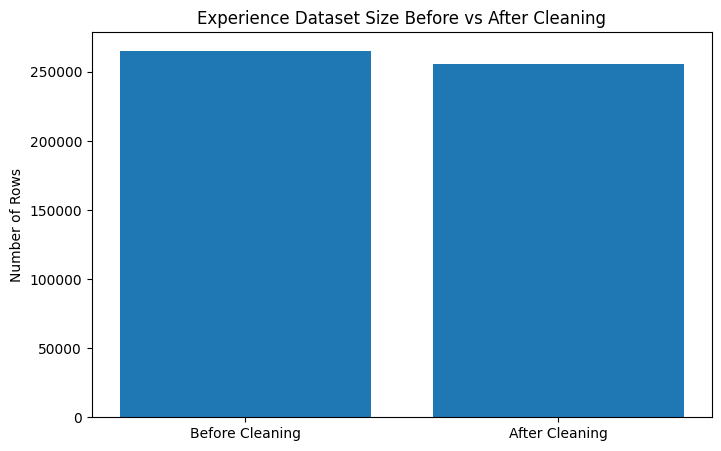

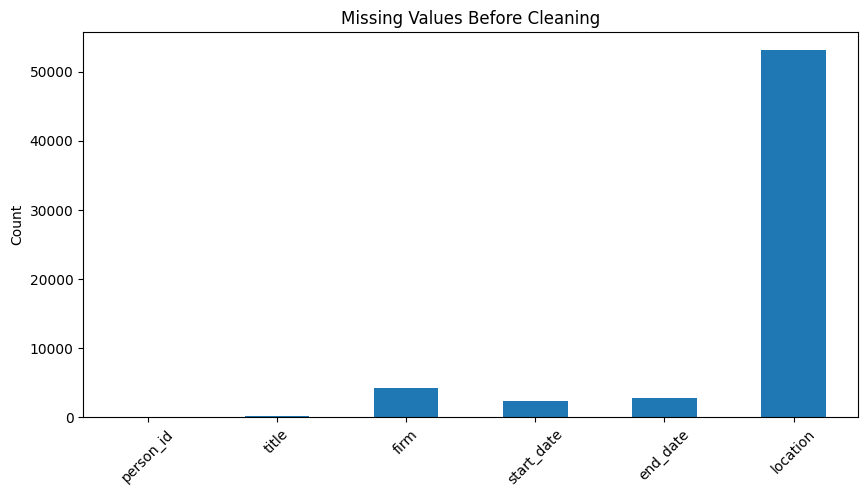

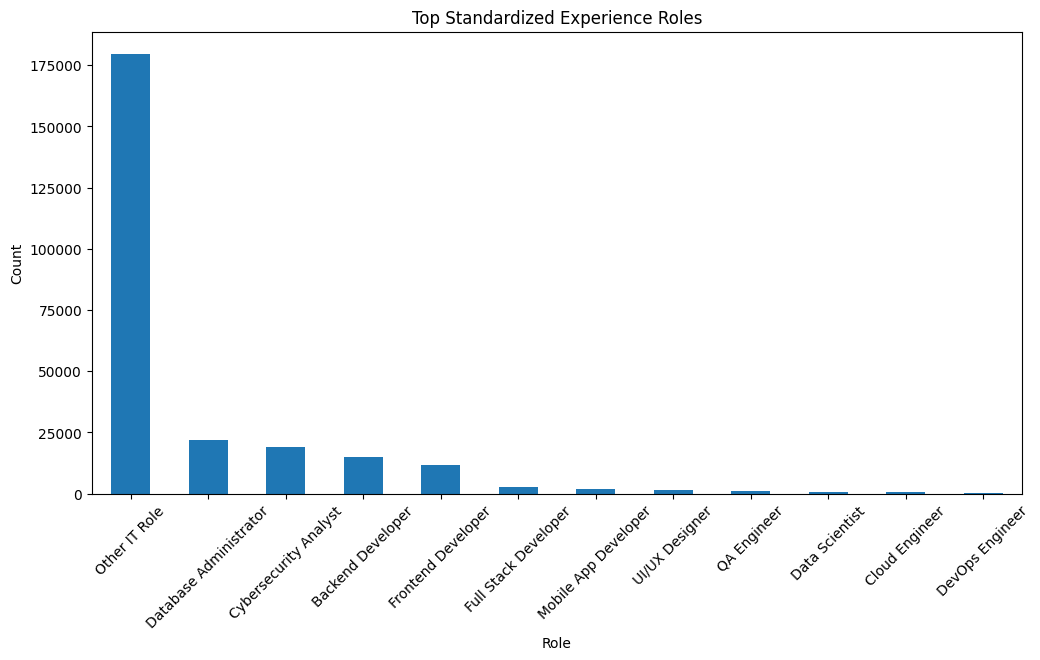

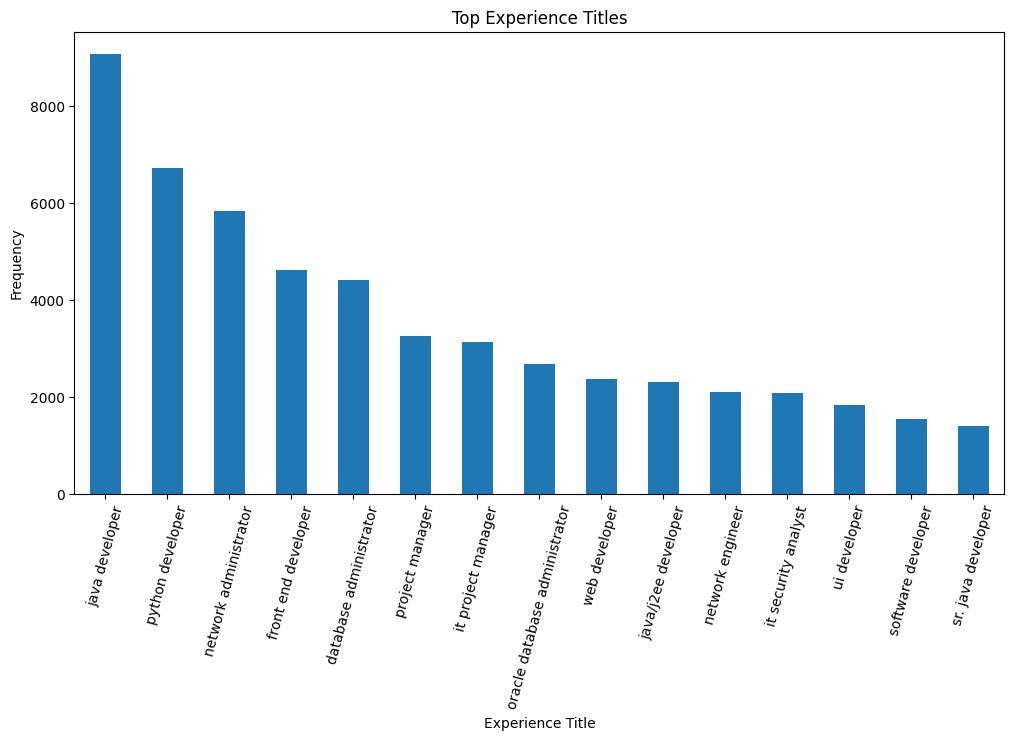

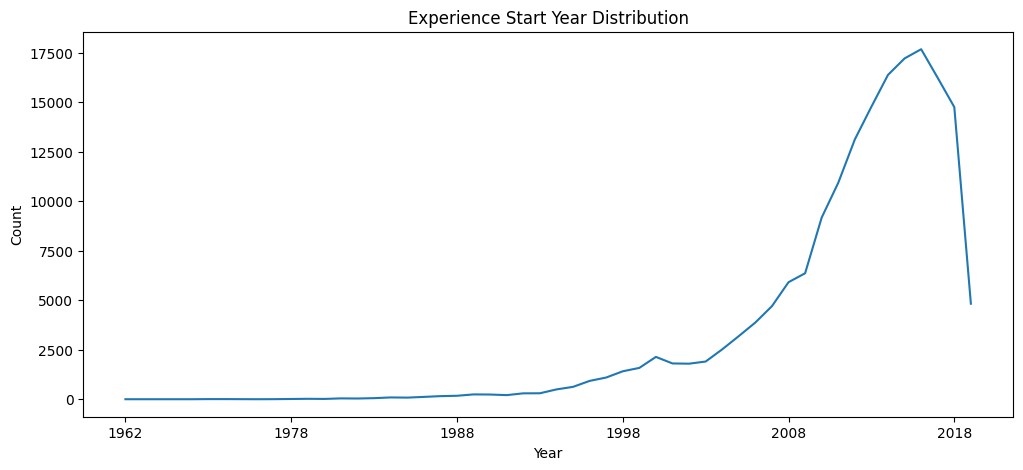


PROCESS COMPLETED SUCCESSFULLY

SUMMARY:

Initial Shape  : (265404, 6)
Final Shape    : (255867, 9)

Operations Performed:
1. Removed Empty Rows
2. Cleaned Experience Titles
3. Cleaned Firm Names
4. Removed Garbage Titles
5. Standardized IT Roles
6. Extracted Start & End Years
7. Removed Duplicate Rows
8. Generated Dataset Analysis
9. Generated Visualization Plots

Saved File:
04_experience_add.csv

IMPORTANT:
This dataset is one of the strongest semantic
signals for role prediction in your project.



In [4]:
# ============================================================
# NLP PROJECT - EXPERIENCE DATASET ANALYSIS & CLEANING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# ============================================================
# 1. LOAD DATASET
# ============================================================

input_path = "/content/drive/MyDrive/NLP_Project-2/Datasets/04_experience.csv"
output_path = "/content/drive/MyDrive/NLP_Project-2/Datasets/04_experience_add.csv"

print("=" * 70)
print("LOADING EXPERIENCE DATASET...")
print("=" * 70)

df = pd.read_csv(input_path)

# ============================================================
# 2. INITIAL DATASET ANALYSIS
# ============================================================

print("\nINITIAL DATASET INFORMATION")
print("=" * 70)

print(f"Initial Shape: {df.shape}")

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nSample Rows:")
print(df.head())

# ============================================================
# 3. STORE INITIAL STATS
# ============================================================

initial_rows = df.shape[0]
initial_columns = df.shape[1]

missing_before = df.isnull().sum()

# ============================================================
# 4. UNDERSTANDING THE DATASET
# ============================================================

print("\n" + "=" * 70)
print("UNDERSTANDING EXPERIENCE DATASET")
print("=" * 70)

print("""
IMPORTANT ROLE OF THIS DATASET:

This dataset is one of the MOST IMPORTANT datasets
for your semantic resume intelligence system.

This dataset helps in:
1. Role Detection
2. Semantic Enrichment
3. Experience Intelligence
4. Skill Confidence
5. Career Prediction

MOST IMPORTANT COLUMNS:
- title      -> VERY HIGH importance
- firm       -> MEDIUM importance
- start_date -> LOW importance
- end_date   -> LOW importance
- location   -> LOW importance
""")

# ============================================================
# 5. REMOVE COMPLETELY EMPTY ROWS
# ============================================================

print("\n" + "=" * 70)
print("REMOVING COMPLETELY EMPTY ROWS...")
print("=" * 70)

before_empty = df.shape[0]

df.dropna(how='all', inplace=True)

after_empty = df.shape[0]

print(f"Completely Empty Rows Removed: {before_empty - after_empty}")

# ============================================================
# 6. CLEAN TEXT COLUMNS
# ============================================================

print("\n" + "=" * 70)
print("CLEANING TEXT COLUMNS...")
print("=" * 70)

text_columns = ['title', 'firm', 'location']

def clean_text(text):

    if pd.isnull(text):
        return np.nan

    text = str(text)

    # lowercase
    text = text.lower()

    # remove special characters
    text = re.sub(r'[^a-zA-Z0-9\s/,+.-]', ' ', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

for col in text_columns:
    if col in df.columns:
        df[col] = df[col].apply(clean_text)

print("Text Cleaning Completed.")

# ============================================================
# 7. REMOVE ROWS WITH MISSING TITLES
# ============================================================

print("\n" + "=" * 70)
print("REMOVING ROWS WITH MISSING TITLES...")
print("=" * 70)

before_title = df.shape[0]

df = df[df['title'].notnull()]

after_title = df.shape[0]

print(f"Rows Removed: {before_title - after_title}")

# ============================================================
# 8. REMOVE GARBAGE TITLES
# ============================================================

print("\n" + "=" * 70)
print("REMOVING GARBAGE EXPERIENCE TITLES...")
print("=" * 70)

garbage_words = [
    'unknown',
    'none',
    'n/a',
    'student',
    'volunteer'
]

def is_valid_title(title):

    if pd.isnull(title):
        return False

    # remove very short titles
    if len(title.split()) < 2:
        return False

    # remove garbage keywords
    for word in garbage_words:
        if word in title:
            return False

    return True

before_garbage = df.shape[0]

df = df[df['title'].apply(is_valid_title)]

after_garbage = df.shape[0]

print(f"Garbage Rows Removed: {before_garbage - after_garbage}")

# ============================================================
# 9. REMOVE DUPLICATE WORD REPETITIONS
# ============================================================

print("\n" + "=" * 70)
print("REMOVING DUPLICATE WORD REPETITIONS...")
print("=" * 70)

def remove_duplicate_words(text):

    if pd.isnull(text):
        return np.nan

    words = text.split()

    cleaned = []

    for word in words:
        if len(cleaned) == 0 or cleaned[-1] != word:
            cleaned.append(word)

    return " ".join(cleaned)

df['title'] = df['title'].apply(remove_duplicate_words)

# ============================================================
# 10. STANDARDIZE EXPERIENCE ROLES
# ============================================================

print("\n" + "=" * 70)
print("STANDARDIZING EXPERIENCE ROLES...")
print("=" * 70)

role_mapping = {

    # DATABASE
    r'.*(oracle|sql|dba|database).*':
        'Database Administrator',

    # FRONTEND
    r'.*(frontend|front end|react|angular|vue).*':
        'Frontend Developer',

    # BACKEND
    r'.*(backend|back end|java developer|spring|node js|django).*':
        'Backend Developer',

    # FULL STACK
    r'.*(full stack).*':
        'Full Stack Developer',

    # DEVOPS
    r'.*(devops|docker|jenkins|terraform|kubernetes).*':
        'DevOps Engineer',

    # CLOUD
    r'.*(cloud|aws|azure|gcp).*':
        'Cloud Engineer',

    # DATA SCIENCE
    r'.*(data scientist|analytics|business intelligence).*':
        'Data Scientist',

    # ML ENGINEER
    r'.*(machine learning|ml engineer|ai engineer|deep learning).*':
        'Machine Learning Engineer',

    # CYBERSECURITY
    r'.*(cyber|security|ethical hacking).*':
        'Cybersecurity Analyst',

    # MOBILE
    r'.*(android|ios|flutter|mobile).*':
        'Mobile App Developer',

    # QA
    r'.*(qa|testing|selenium|test engineer).*':
        'QA Engineer',

    # UI UX
    r'.*(ux|ui designer|figma).*':
        'UI/UX Designer'
}

def map_role(title):

    if pd.isnull(title):
        return "Unknown"

    for pattern, role in role_mapping.items():
        if re.search(pattern, title):
            return role

    return "Other IT Role"

df['standardized_role'] = df['title'].apply(map_role)

# ============================================================
# 11. EXTRACT EXPERIENCE YEARS
# ============================================================

print("\n" + "=" * 70)
print("EXTRACTING EXPERIENCE YEARS...")
print("=" * 70)

def extract_year(date):

    if pd.isnull(date):
        return np.nan

    match = re.search(r'(19|20)\d{2}', str(date))

    if match:
        return match.group()

    return np.nan

df['start_year'] = df['start_date'].apply(extract_year)
df['end_year'] = df['end_date'].apply(extract_year)

print("Year Extraction Completed.")

# ============================================================
# 12. REMOVE DUPLICATES
# ============================================================

print("\n" + "=" * 70)
print("REMOVING DUPLICATE ROWS...")
print("=" * 70)

before_dup = df.shape[0]

df.drop_duplicates(inplace=True)

after_dup = df.shape[0]

print(f"Duplicate Rows Removed: {before_dup - after_dup}")

# ============================================================
# 13. EXPERIENCE TITLE ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("TOP EXPERIENCE TITLES")
print("=" * 70)

top_titles = df['title'].value_counts().head(20)

print(top_titles)

# ============================================================
# 14. ROLE DISTRIBUTION ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("STANDARDIZED ROLE DISTRIBUTION")
print("=" * 70)

role_counts = df['standardized_role'].value_counts()

print(role_counts)

# ============================================================
# 15. COMPANY ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("TOP FIRMS / COMPANIES")
print("=" * 70)

top_firms = df['firm'].value_counts().head(15)

print(top_firms)

# ============================================================
# 16. FINAL DATASET INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("FINAL DATASET INFORMATION")
print("=" * 70)

print(f"Final Shape: {df.shape}")

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nDuplicate Rows After Cleaning:")
print(df.duplicated().sum())

print("\nFinal Columns:")
print(df.columns.tolist())

print("\nSample Cleaned Data:")
print(df.head())

# ============================================================
# 17. SAVE CLEANED DATASET
# ============================================================

print("\n" + "=" * 70)
print("SAVING CLEANED DATASET...")
print("=" * 70)

df.to_csv(output_path, index=False)

print(f"Dataset Saved Successfully:")
print(output_path)

# ============================================================
# 18. GENERATE VISUALIZATIONS
# ============================================================

print("\n" + "=" * 70)
print("GENERATING PLOTS...")
print("=" * 70)

# ------------------------------------------------------------
# Plot 1 - Before vs After Cleaning
# ------------------------------------------------------------

final_rows = df.shape[0]

plt.figure(figsize=(8, 5))

plt.bar(
    ['Before Cleaning', 'After Cleaning'],
    [initial_rows, final_rows]
)

plt.title("Experience Dataset Size Before vs After Cleaning")
plt.ylabel("Number of Rows")

plt.show()

# ------------------------------------------------------------
# Plot 2 - Missing Values Before Cleaning
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

missing_before.plot(kind='bar')

plt.title("Missing Values Before Cleaning")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# ------------------------------------------------------------
# Plot 3 - Top Standardized Roles
# ------------------------------------------------------------

top_roles = df['standardized_role'].value_counts().head(12)

plt.figure(figsize=(12, 6))

top_roles.plot(kind='bar')

plt.title("Top Standardized Experience Roles")
plt.xlabel("Role")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# ------------------------------------------------------------
# Plot 4 - Top Experience Titles
# ------------------------------------------------------------

top_titles_plot = df['title'].value_counts().head(15)

plt.figure(figsize=(12, 6))

top_titles_plot.plot(kind='bar')

plt.title("Top Experience Titles")
plt.xlabel("Experience Title")
plt.ylabel("Frequency")

plt.xticks(rotation=75)

plt.show()

# ------------------------------------------------------------
# Plot 5 - Experience Start Year Distribution
# ------------------------------------------------------------

year_data = df['start_year'].dropna()

plt.figure(figsize=(12, 5))

year_data.value_counts().sort_index().plot(kind='line')

plt.title("Experience Start Year Distribution")
plt.xlabel("Year")
plt.ylabel("Count")

plt.show()

# ============================================================
# 19. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("PROCESS COMPLETED SUCCESSFULLY")
print("=" * 70)

print(f"""
SUMMARY:

Initial Shape  : ({initial_rows}, {initial_columns})
Final Shape    : {df.shape}

Operations Performed:
1. Removed Empty Rows
2. Cleaned Experience Titles
3. Cleaned Firm Names
4. Removed Garbage Titles
5. Standardized IT Roles
6. Extracted Start & End Years
7. Removed Duplicate Rows
8. Generated Dataset Analysis
9. Generated Visualization Plots

Saved File:
04_experience_add.csv

IMPORTANT:
This dataset is one of the strongest semantic
signals for role prediction in your project.
""")

`05_person_skills.csv` data set Cleaning missing values

LOADING PERSON SKILLS DATASET...

INITIAL DATASET INFORMATION
Initial Shape: (2483376, 2)

Columns:
['person_id', 'skill']

Data Types:
person_id     int64
skill        object
dtype: object

Missing Values:
person_id    0
skill        9
dtype: int64

Duplicate Rows:
587511

Sample Rows:
   person_id                    skill
0          1  Database administration
1          1                 Database
2          1            Ms sql server
3          1       Ms sql server 2005
4          1               Sql server

UNDERSTANDING PERSON SKILLS DATASET

IMPORTANT:
This is the MOST IMPORTANT dataset
for your entire semantic intelligence framework.

This dataset powers:
1. Role Prediction
2. Semantic Embeddings
3. Clustering
4. Skill Gap Analysis
5. Recommendation Engine
6. Resume Intelligence

MAIN SIGNAL:
person_id + skill


REMOVING COMPLETELY EMPTY ROWS...
Completely Empty Rows Removed: 0

REMOVING NULL SKILLS...
Rows Removed: 9

CLEANING SKILL TEXT...
Skill Cleaning Completed.

REMOVING E

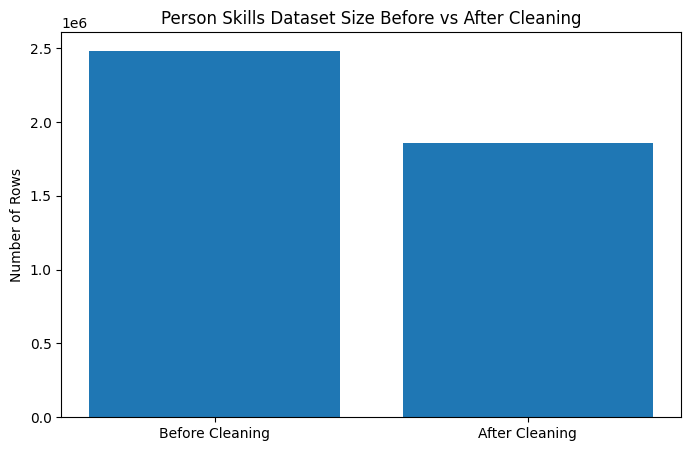

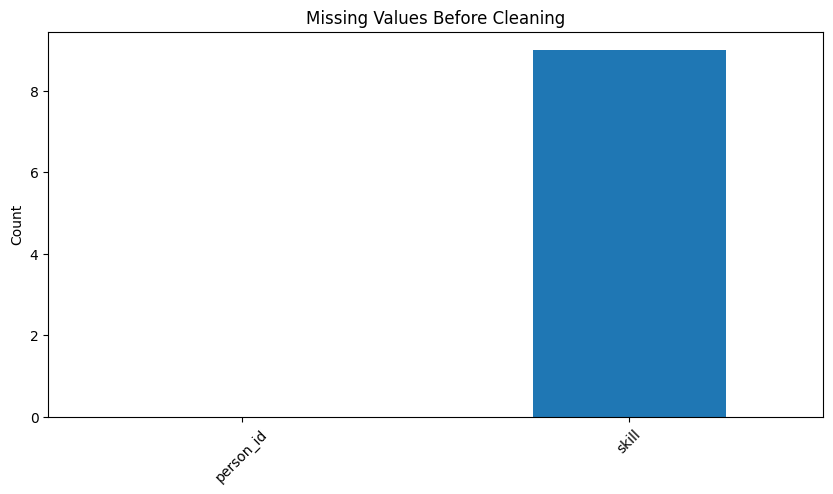

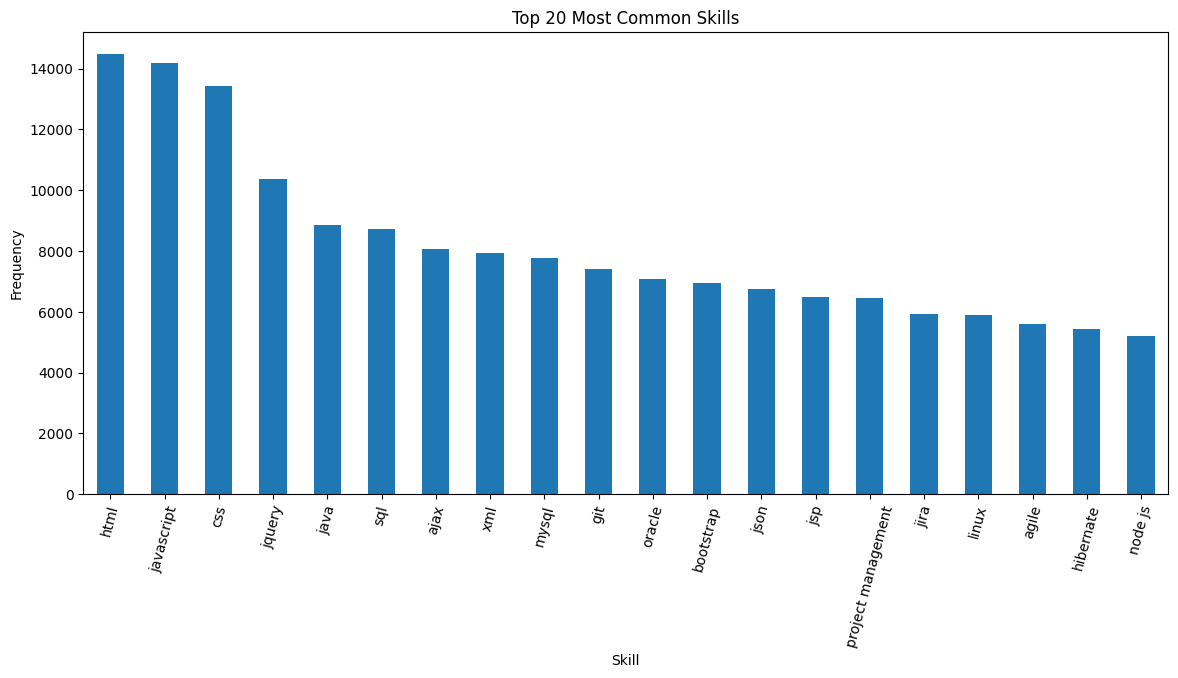

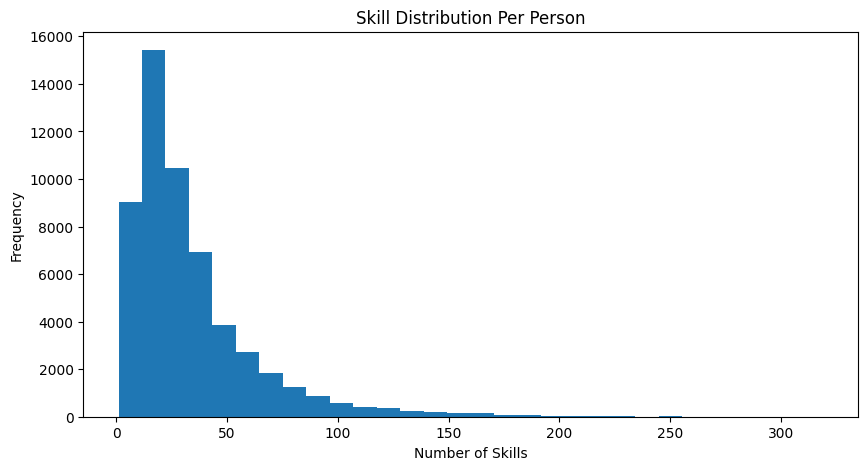

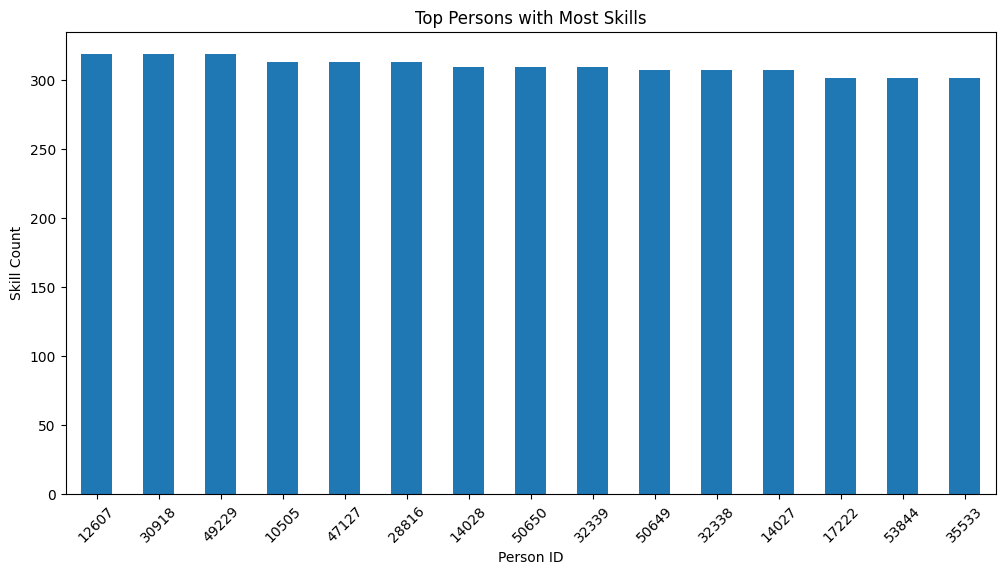


PROCESS COMPLETED SUCCESSFULLY

SUMMARY:

Initial Shape  : (2483376, 2)
Final Shape    : (1860156, 2)

Operations Performed:
1. Removed Empty Rows
2. Removed Null Skills
3. Cleaned Skill Text
4. Removed Empty Skills
5. Removed Garbage Skills
6. Standardized Skills
7. Removed Duplicate Rows
8. Skill Distribution Analysis
9. Visualization Generation

Saved File:
05_person_skills_add.csv

IMPORTANT:
This dataset is the CORE semantic signal
for your NLP project.



In [5]:
# ============================================================
# NLP PROJECT - PERSON SKILLS DATASET CLEANING & ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# ============================================================
# 1. LOAD DATASET
# ============================================================

input_path = "/content/drive/MyDrive/NLP_Project-2/Datasets/05_person_skills.csv"
output_path = "/content/drive/MyDrive/NLP_Project-2/Datasets/05_person_skills_add.csv"

print("=" * 70)
print("LOADING PERSON SKILLS DATASET...")
print("=" * 70)

df = pd.read_csv(input_path)

# ============================================================
# 2. INITIAL DATASET INFORMATION
# ============================================================

print("\nINITIAL DATASET INFORMATION")
print("=" * 70)

print(f"Initial Shape: {df.shape}")

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nSample Rows:")
print(df.head())

# ============================================================
# 3. STORE INITIAL STATS
# ============================================================

initial_rows = df.shape[0]
initial_columns = df.shape[1]

missing_before = df.isnull().sum()

# ============================================================
# 4. UNDERSTANDING DATASET
# ============================================================

print("\n" + "=" * 70)
print("UNDERSTANDING PERSON SKILLS DATASET")
print("=" * 70)

print("""
IMPORTANT:
This is the MOST IMPORTANT dataset
for your entire semantic intelligence framework.

This dataset powers:
1. Role Prediction
2. Semantic Embeddings
3. Clustering
4. Skill Gap Analysis
5. Recommendation Engine
6. Resume Intelligence

MAIN SIGNAL:
person_id + skill
""")

# ============================================================
# 5. REMOVE COMPLETELY EMPTY ROWS
# ============================================================

print("\n" + "=" * 70)
print("REMOVING COMPLETELY EMPTY ROWS...")
print("=" * 70)

before_empty = df.shape[0]

df.dropna(how='all', inplace=True)

after_empty = df.shape[0]

print(f"Completely Empty Rows Removed: {before_empty - after_empty}")

# ============================================================
# 6. REMOVE ROWS WITH NULL SKILLS
# ============================================================

print("\n" + "=" * 70)
print("REMOVING NULL SKILLS...")
print("=" * 70)

before_null = df.shape[0]

df = df[df['skill'].notnull()]

after_null = df.shape[0]

print(f"Rows Removed: {before_null - after_null}")

# ============================================================
# 7. CLEAN SKILL TEXT
# ============================================================

print("\n" + "=" * 70)
print("CLEANING SKILL TEXT...")
print("=" * 70)

def clean_skill(skill):

    if pd.isnull(skill):
        return np.nan

    skill = str(skill)

    # lowercase
    skill = skill.lower()

    # remove special characters
    skill = re.sub(r'[^a-zA-Z0-9\s/#+.-]', ' ', skill)

    # remove extra spaces
    skill = re.sub(r'\s+', ' ', skill).strip()

    return skill

df['skill'] = df['skill'].apply(clean_skill)

print("Skill Cleaning Completed.")

# ============================================================
# 8. REMOVE EMPTY SKILLS
# ============================================================

print("\n" + "=" * 70)
print("REMOVING EMPTY SKILLS...")
print("=" * 70)

before_empty_skill = df.shape[0]

df = df[df['skill'].str.strip() != ""]

after_empty_skill = df.shape[0]

print(f"Empty Skill Rows Removed: {before_empty_skill - after_empty_skill}")

# ============================================================
# 9. REMOVE DUPLICATE WORD REPETITIONS
# ============================================================

print("\n" + "=" * 70)
print("REMOVING DUPLICATE WORD REPETITIONS...")
print("=" * 70)

def remove_duplicate_words(text):

    if pd.isnull(text):
        return np.nan

    words = text.split()

    cleaned = []

    for word in words:
        if len(cleaned) == 0 or cleaned[-1] != word:
            cleaned.append(word)

    return " ".join(cleaned)

df['skill'] = df['skill'].apply(remove_duplicate_words)

# ============================================================
# 10. REMOVE GARBAGE SKILLS
# ============================================================

print("\n" + "=" * 70)
print("REMOVING GARBAGE SKILLS...")
print("=" * 70)

garbage_skills = [
    'unknown',
    'none',
    'null',
    'n/a',
    'na',
    'test',
    'sample'
]

def is_valid_skill(skill):

    if pd.isnull(skill):
        return False

    # very short garbage
    if len(skill.strip()) < 2:
        return False

    # remove garbage skills
    for word in garbage_skills:
        if skill == word:
            return False

    return True

before_garbage = df.shape[0]

df = df[df['skill'].apply(is_valid_skill)]

after_garbage = df.shape[0]

print(f"Garbage Skills Removed: {before_garbage - after_garbage}")

# ============================================================
# 11. STANDARDIZE SKILLS
# ============================================================

print("\n" + "=" * 70)
print("STANDARDIZING SKILLS...")
print("=" * 70)

skill_mapping = {

    # FRONTEND
    'reactjs': 'react',
    'react.js': 'react',
    'html5': 'html',
    'css3': 'css',
    'javascript es6': 'javascript',

    # BACKEND
    'nodejs': 'node js',
    'node.js': 'node js',
    'expressjs': 'express js',

    # DATABASE
    'mysql database': 'mysql',
    'mssql': 'sql server',
    'oracle db': 'oracle',

    # DEVOPS
    'k8s': 'kubernetes',
    'docker container': 'docker',

    # AI / ML
    'tensorflow keras': 'tensorflow',
    'pytorch deep learning': 'pytorch',

    # CLOUD
    'amazon web services': 'aws',
    'google cloud platform': 'gcp'
}

df['skill'] = df['skill'].replace(skill_mapping)

print("Skill Standardization Completed.")

# ============================================================
# 12. REMOVE DUPLICATES
# ============================================================

print("\n" + "=" * 70)
print("REMOVING DUPLICATE ROWS...")
print("=" * 70)

before_dup = df.shape[0]

df.drop_duplicates(inplace=True)

after_dup = df.shape[0]

print(f"Duplicate Rows Removed: {before_dup - after_dup}")

# ============================================================
# 13. SKILL ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("TOP SKILLS ANALYSIS")
print("=" * 70)

top_skills = df['skill'].value_counts().head(30)

print(top_skills)

# ============================================================
# 14. UNIQUE SKILL ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("UNIQUE SKILL ANALYSIS")
print("=" * 70)

unique_skills = df['skill'].nunique()

print(f"Total Unique Skills: {unique_skills}")

# ============================================================
# 15. PERSON SKILL DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("SKILL DISTRIBUTION PER PERSON")
print("=" * 70)

person_skill_counts = df.groupby('person_id')['skill'].count()

print(person_skill_counts.describe())

# ============================================================
# 16. FINAL DATASET INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("FINAL DATASET INFORMATION")
print("=" * 70)

print(f"Final Shape: {df.shape}")

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nDuplicate Rows After Cleaning:")
print(df.duplicated().sum())

print("\nFinal Columns:")
print(df.columns.tolist())

print("\nSample Cleaned Data:")
print(df.head())

# ============================================================
# 17. SAVE CLEANED DATASET
# ============================================================

print("\n" + "=" * 70)
print("SAVING CLEANED DATASET...")
print("=" * 70)

df.to_csv(output_path, index=False)

print(f"Dataset Saved Successfully:")
print(output_path)

# ============================================================
# 18. GENERATE VISUALIZATIONS
# ============================================================

print("\n" + "=" * 70)
print("GENERATING PLOTS...")
print("=" * 70)

# ------------------------------------------------------------
# Plot 1 - Before vs After Cleaning
# ------------------------------------------------------------

final_rows = df.shape[0]

plt.figure(figsize=(8, 5))

plt.bar(
    ['Before Cleaning', 'After Cleaning'],
    [initial_rows, final_rows]
)

plt.title("Person Skills Dataset Size Before vs After Cleaning")
plt.ylabel("Number of Rows")

plt.show()

# ------------------------------------------------------------
# Plot 2 - Missing Values Before Cleaning
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

missing_before.plot(kind='bar')

plt.title("Missing Values Before Cleaning")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# ------------------------------------------------------------
# Plot 3 - Top 20 Skills
# ------------------------------------------------------------

top_plot = df['skill'].value_counts().head(20)

plt.figure(figsize=(14, 6))

top_plot.plot(kind='bar')

plt.title("Top 20 Most Common Skills")
plt.xlabel("Skill")
plt.ylabel("Frequency")

plt.xticks(rotation=75)

plt.show()

# ------------------------------------------------------------
# Plot 4 - Skill Distribution Per Person
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.hist(person_skill_counts, bins=30)

plt.title("Skill Distribution Per Person")
plt.xlabel("Number of Skills")
plt.ylabel("Frequency")

plt.show()

# ------------------------------------------------------------
# Plot 5 - Top Persons with Most Skills
# ------------------------------------------------------------

top_people = person_skill_counts.sort_values(
    ascending=False
).head(15)

plt.figure(figsize=(12, 6))

top_people.plot(kind='bar')

plt.title("Top Persons with Most Skills")
plt.xlabel("Person ID")
plt.ylabel("Skill Count")

plt.xticks(rotation=45)

plt.show()

# ============================================================
# 19. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("PROCESS COMPLETED SUCCESSFULLY")
print("=" * 70)

print(f"""
SUMMARY:

Initial Shape  : ({initial_rows}, {initial_columns})
Final Shape    : {df.shape}

Operations Performed:
1. Removed Empty Rows
2. Removed Null Skills
3. Cleaned Skill Text
4. Removed Empty Skills
5. Removed Garbage Skills
6. Standardized Skills
7. Removed Duplicate Rows
8. Skill Distribution Analysis
9. Visualization Generation

Saved File:
05_person_skills_add.csv

IMPORTANT:
This dataset is the CORE semantic signal
for your NLP project.
""")

`06_skills.csv` data set Cleaning missing values

LOADING GLOBAL SKILLS DATASET...

INITIAL DATASET INFORMATION
Initial Shape: (226760, 1)

Columns:
['skill']

Data Types:
skill    object
dtype: object

Missing Values:
skill    2
dtype: int64

Duplicate Rows:
1

Sample Rows:
                                               skill
0                                       Mongo DB-3.2
1                                          JNDI LDAP
2                                  Stored Procedures
3                            Perform ad-hoc analysis
4  Monitored and resolved flight crew legality is...

UNDERSTANDING GLOBAL SKILLS DATASET

IMPORTANT:
This dataset is the MASTER SKILL VOCABULARY.

This dataset helps in:
1. Skill Standardization
2. Skill Validation
3. Semantic Vocabulary Building
4. Skill Clustering
5. Recommendation Engine
6. Skill Gap Analysis

MAIN SIGNAL:
skill


REMOVING COMPLETELY EMPTY ROWS...
Completely Empty Rows Removed: 2

REMOVING NULL SKILLS...
Rows Removed Due to Null Skills: 0

CLEANING SKILL TEXT...
Skill Cleaning Comple

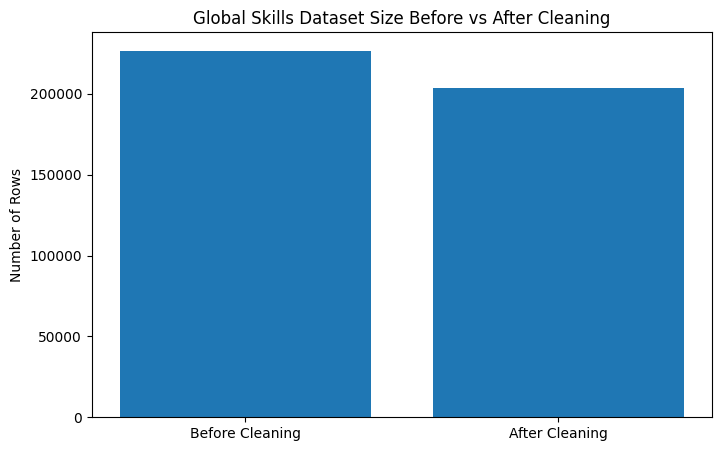

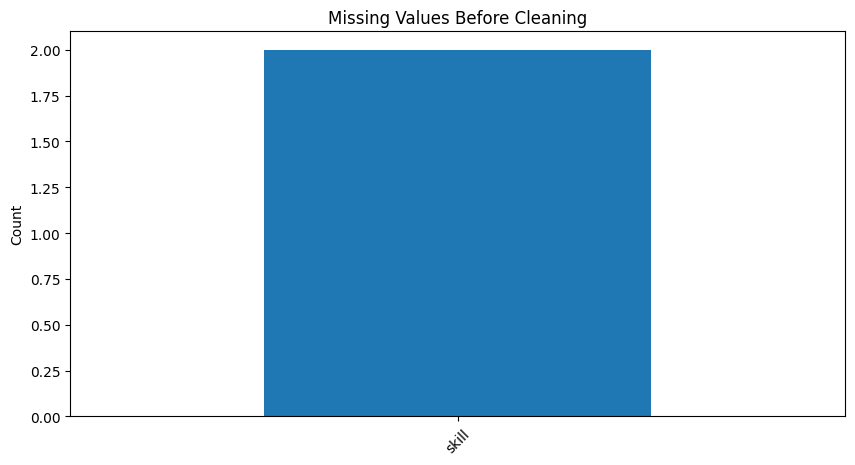

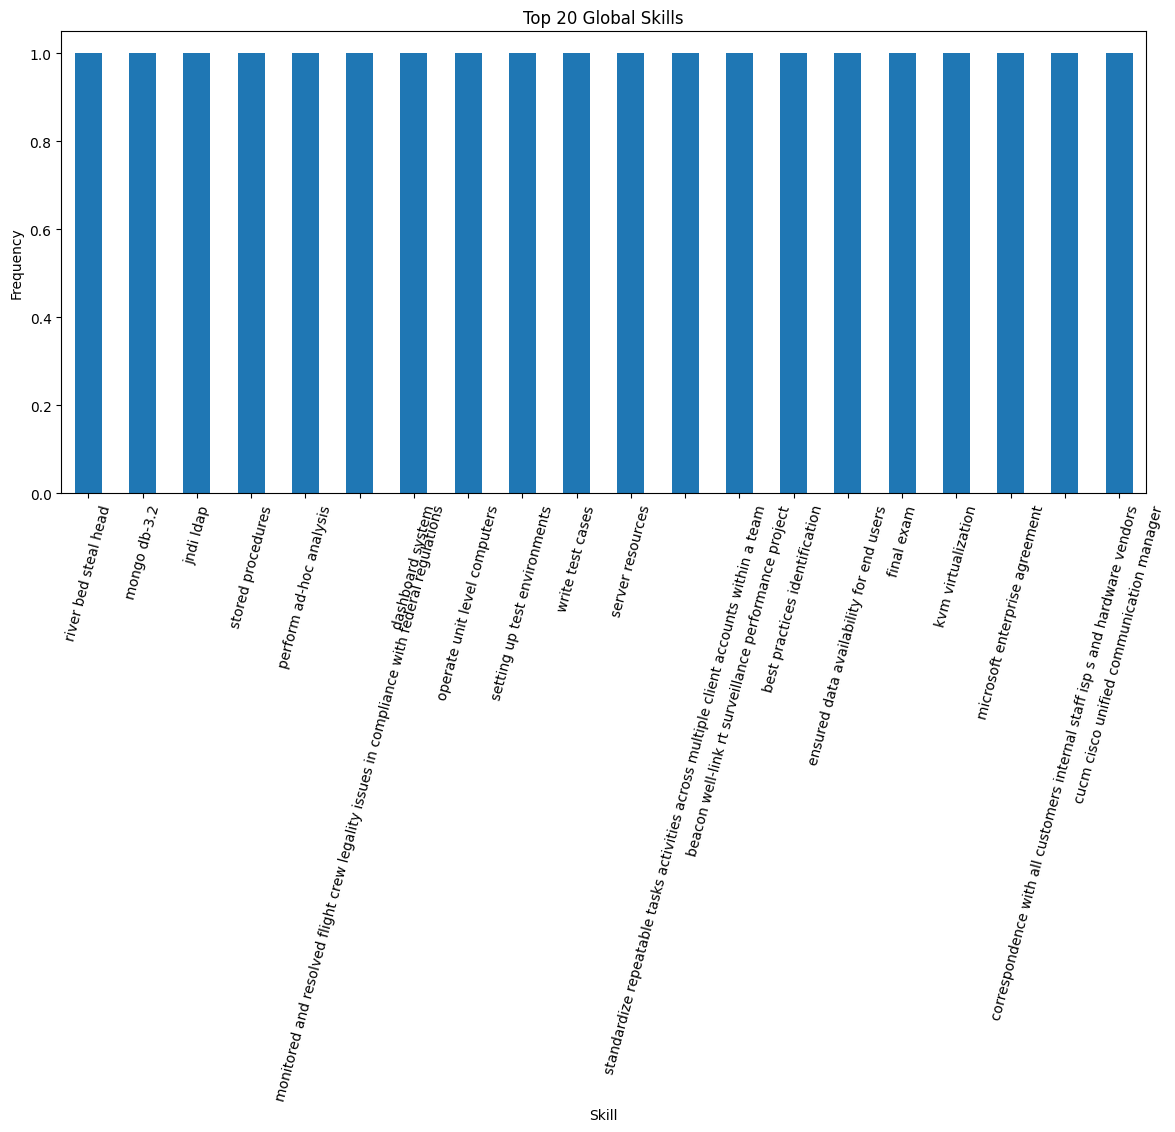

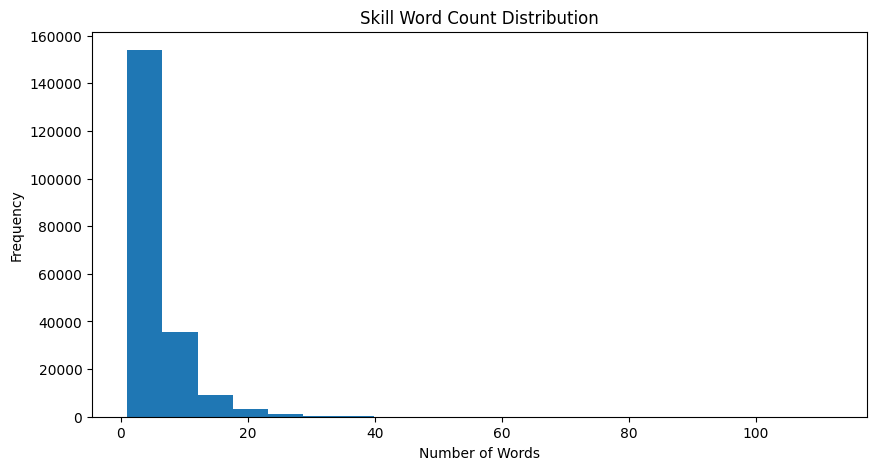

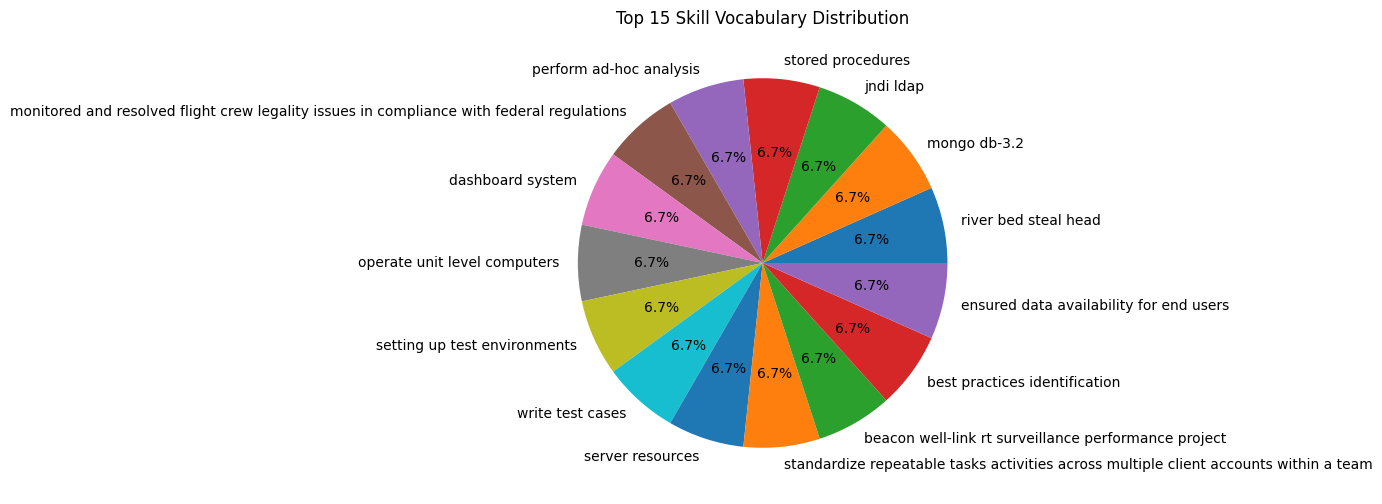


PROCESS COMPLETED SUCCESSFULLY

SUMMARY:

Initial Shape  : (226760, 1)
Final Shape    : (203710, 2)

Operations Performed:
1. Removed Empty Rows
2. Removed Null Skills
3. Cleaned Skill Text
4. Removed Empty Skills
5. Removed Garbage Skills
6. Standardized Skill Names
7. Removed Duplicate Skills
8. Generated Skill Analysis
9. Generated Visualization Plots

Saved File:
06_skills_add.csv

IMPORTANT:
This dataset acts as the MASTER
semantic skill vocabulary for your project.



In [6]:
# ============================================================
# NLP PROJECT - GLOBAL SKILLS DATASET CLEANING & ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# ============================================================
# 1. LOAD DATASET
# ============================================================

input_path = "/content/drive/MyDrive/NLP_Project-2/Datasets/06_skills.csv"
output_path = "/content/drive/MyDrive/NLP_Project-2/Datasets/06_skills_add.csv"

print("=" * 70)
print("LOADING GLOBAL SKILLS DATASET...")
print("=" * 70)

df = pd.read_csv(input_path)

# ============================================================
# 2. INITIAL DATASET INFORMATION
# ============================================================

print("\nINITIAL DATASET INFORMATION")
print("=" * 70)

print(f"Initial Shape: {df.shape}")

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nSample Rows:")
print(df.head())

# ============================================================
# 3. STORE INITIAL STATS
# ============================================================

initial_rows = df.shape[0]
initial_columns = df.shape[1]

missing_before = df.isnull().sum()

# ============================================================
# 4. UNDERSTANDING DATASET
# ============================================================

print("\n" + "=" * 70)
print("UNDERSTANDING GLOBAL SKILLS DATASET")
print("=" * 70)

print("""
IMPORTANT:
This dataset is the MASTER SKILL VOCABULARY.

This dataset helps in:
1. Skill Standardization
2. Skill Validation
3. Semantic Vocabulary Building
4. Skill Clustering
5. Recommendation Engine
6. Skill Gap Analysis

MAIN SIGNAL:
skill
""")

# ============================================================
# 5. REMOVE COMPLETELY EMPTY ROWS
# ============================================================

print("\n" + "=" * 70)
print("REMOVING COMPLETELY EMPTY ROWS...")
print("=" * 70)

before_empty = df.shape[0]

df.dropna(how='all', inplace=True)

after_empty = df.shape[0]

print(f"Completely Empty Rows Removed: {before_empty - after_empty}")

# ============================================================
# 6. REMOVE NULL SKILLS
# ============================================================

print("\n" + "=" * 70)
print("REMOVING NULL SKILLS...")
print("=" * 70)

before_null = df.shape[0]

df = df[df['skill'].notnull()]

after_null = df.shape[0]

print(f"Rows Removed Due to Null Skills: {before_null - after_null}")

# ============================================================
# 7. CLEAN SKILL TEXT
# ============================================================

print("\n" + "=" * 70)
print("CLEANING SKILL TEXT...")
print("=" * 70)

def clean_skill(skill):

    if pd.isnull(skill):
        return np.nan

    skill = str(skill)

    # lowercase
    skill = skill.lower()

    # remove special characters
    skill = re.sub(r'[^a-zA-Z0-9\s/#+.-]', ' ', skill)

    # remove extra spaces
    skill = re.sub(r'\s+', ' ', skill).strip()

    return skill

df['skill'] = df['skill'].apply(clean_skill)

print("Skill Cleaning Completed.")

# ============================================================
# 8. REMOVE EMPTY SKILLS
# ============================================================

print("\n" + "=" * 70)
print("REMOVING EMPTY SKILLS...")
print("=" * 70)

before_empty_skill = df.shape[0]

df = df[df['skill'].str.strip() != ""]

after_empty_skill = df.shape[0]

print(f"Empty Skill Rows Removed: {before_empty_skill - after_empty_skill}")

# ============================================================
# 9. REMOVE DUPLICATE WORD REPETITIONS
# ============================================================

print("\n" + "=" * 70)
print("REMOVING DUPLICATE WORD REPETITIONS...")
print("=" * 70)

def remove_duplicate_words(text):

    if pd.isnull(text):
        return np.nan

    words = text.split()

    cleaned = []

    for word in words:
        if len(cleaned) == 0 or cleaned[-1] != word:
            cleaned.append(word)

    return " ".join(cleaned)

df['skill'] = df['skill'].apply(remove_duplicate_words)

# ============================================================
# 10. REMOVE GARBAGE SKILLS
# ============================================================

print("\n" + "=" * 70)
print("REMOVING GARBAGE SKILLS...")
print("=" * 70)

garbage_skills = [
    'unknown',
    'none',
    'null',
    'n/a',
    'na',
    'test',
    'sample',
    '-',
    '--'
]

def is_valid_skill(skill):

    if pd.isnull(skill):
        return False

    # remove extremely short garbage
    if len(skill.strip()) < 2:
        return False

    # remove garbage words
    for word in garbage_skills:
        if skill == word:
            return False

    return True

before_garbage = df.shape[0]

df = df[df['skill'].apply(is_valid_skill)]

after_garbage = df.shape[0]

print(f"Garbage Skills Removed: {before_garbage - after_garbage}")

# ============================================================
# 11. STANDARDIZE SKILLS
# ============================================================

print("\n" + "=" * 70)
print("STANDARDIZING SKILLS...")
print("=" * 70)

skill_mapping = {

    # FRONTEND
    'reactjs': 'react',
    'react.js': 'react',
    'html5': 'html',
    'css3': 'css',
    'js': 'javascript',

    # BACKEND
    'nodejs': 'node js',
    'node.js': 'node js',
    'expressjs': 'express js',

    # DATABASE
    'mysql database': 'mysql',
    'mssql': 'sql server',
    'oracle db': 'oracle',

    # DEVOPS
    'k8s': 'kubernetes',
    'docker container': 'docker',

    # AI / ML
    'tensorflow keras': 'tensorflow',
    'pytorch deep learning': 'pytorch',

    # CLOUD
    'amazon web services': 'aws',
    'google cloud platform': 'gcp'
}

df['skill'] = df['skill'].replace(skill_mapping)

print("Skill Standardization Completed.")

# ============================================================
# 12. REMOVE DUPLICATES
# ============================================================

print("\n" + "=" * 70)
print("REMOVING DUPLICATE SKILLS...")
print("=" * 70)

before_dup = df.shape[0]

df.drop_duplicates(inplace=True)

after_dup = df.shape[0]

print(f"Duplicate Skills Removed: {before_dup - after_dup}")

# ============================================================
# 13. SKILL LENGTH ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("SKILL LENGTH ANALYSIS")
print("=" * 70)

df['skill_word_count'] = df['skill'].apply(
    lambda x: len(str(x).split())
)

print(df['skill_word_count'].describe())

# ============================================================
# 14. TOP SKILLS ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("TOP GLOBAL SKILLS")
print("=" * 70)

top_skills = df['skill'].value_counts().head(30)

print(top_skills)

# ============================================================
# 15. UNIQUE SKILL ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("UNIQUE SKILLS ANALYSIS")
print("=" * 70)

unique_skills = df['skill'].nunique()

print(f"Total Unique Skills: {unique_skills}")

# ============================================================
# 16. FINAL DATASET INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("FINAL DATASET INFORMATION")
print("=" * 70)

print(f"Final Shape: {df.shape}")

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nDuplicate Rows After Cleaning:")
print(df.duplicated().sum())

print("\nFinal Columns:")
print(df.columns.tolist())

print("\nSample Cleaned Data:")
print(df.head())

# ============================================================
# 17. SAVE CLEANED DATASET
# ============================================================

print("\n" + "=" * 70)
print("SAVING CLEANED DATASET...")
print("=" * 70)

# remove temporary column before saving
df.drop(columns=['skill_word_count'], inplace=True)

df.to_csv(output_path, index=False)

print(f"Dataset Saved Successfully:")
print(output_path)

# ============================================================
# 18. GENERATE VISUALIZATIONS
# ============================================================

print("\n" + "=" * 70)
print("GENERATING PLOTS...")
print("=" * 70)

# ------------------------------------------------------------
# Plot 1 - Before vs After Cleaning
# ------------------------------------------------------------

final_rows = df.shape[0]

plt.figure(figsize=(8, 5))

plt.bar(
    ['Before Cleaning', 'After Cleaning'],
    [initial_rows, final_rows]
)

plt.title("Global Skills Dataset Size Before vs After Cleaning")
plt.ylabel("Number of Rows")

plt.show()

# ------------------------------------------------------------
# Plot 2 - Missing Values Before Cleaning
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

missing_before.plot(kind='bar')

plt.title("Missing Values Before Cleaning")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# ------------------------------------------------------------
# Plot 3 - Top 20 Global Skills
# ------------------------------------------------------------

top_plot = df['skill'].value_counts().head(20)

plt.figure(figsize=(14, 6))

top_plot.plot(kind='bar')

plt.title("Top 20 Global Skills")
plt.xlabel("Skill")
plt.ylabel("Frequency")

plt.xticks(rotation=75)

plt.show()

# ------------------------------------------------------------
# Plot 4 - Skill Word Count Distribution
# ------------------------------------------------------------

df['skill_word_count'] = df['skill'].apply(
    lambda x: len(str(x).split())
)

plt.figure(figsize=(10, 5))

plt.hist(df['skill_word_count'], bins=20)

plt.title("Skill Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

# ------------------------------------------------------------
# Plot 5 - Skill Vocabulary Diversity
# ------------------------------------------------------------

top_15 = df['skill'].value_counts().head(15)

plt.figure(figsize=(12, 6))

top_15.plot(kind='pie', autopct='%1.1f%%')

plt.title("Top 15 Skill Vocabulary Distribution")
plt.ylabel("")

plt.show()

# ============================================================
# 19. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("PROCESS COMPLETED SUCCESSFULLY")
print("=" * 70)

print(f"""
SUMMARY:

Initial Shape  : ({initial_rows}, {initial_columns})
Final Shape    : {df.shape}

Operations Performed:
1. Removed Empty Rows
2. Removed Null Skills
3. Cleaned Skill Text
4. Removed Empty Skills
5. Removed Garbage Skills
6. Standardized Skill Names
7. Removed Duplicate Skills
8. Generated Skill Analysis
9. Generated Visualization Plots

Saved File:
06_skills_add.csv

IMPORTANT:
This dataset acts as the MASTER
semantic skill vocabulary for your project.
""")